***Importing Libraries***

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import seaborn as sns

***Importing Initial Dataset***

In [2]:
path = "second_collected_data.csv"

df = pd.read_csv(path)

print(df)

               Type  Area  Year      Location Country  Number of Floors  \
0           Modular  1081  2023       Alabama      US               1.0   
1           Modular  1777  2023       Alabama      US               1.0   
2           Modular  1142  2022       Alabama      US               1.0   
3           Modular  1879  2022       Alabama      US               1.0   
4           Modular  1202  2021       Alabama      US               1.0   
...             ...   ...   ...           ...     ...               ...   
18413  Conventional  1688  2021  Saskatchewan  Canada               2.0   
18414  Conventional  1708  2020  Saskatchewan  Canada               2.0   
18415  Conventional  1728  2020  Saskatchewan  Canada               2.0   
18416  Conventional  1748  2019  Saskatchewan  Canada               2.0   
18417  Conventional  1768  2019  Saskatchewan  Canada               2.0   

                      Material Initial Cost  
0      Vinyl Siding Wood Frame     82300.00  
1      

***Exploratory Data Analysis***

***Initial Cost vs Area***

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = "second_collected_data.csv"
df = pd.read_csv(path)

# 1) Clean headers & values
df.columns = df.columns.str.strip()  # remove trailing spaces
df = df.rename(columns={"Type of Building":"Type"})  # if needed

for c in ["Type","Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Remove currency symbols/commas and convert to numeric
def to_num(s):
    return pd.to_numeric(
        pd.Series(s).astype(str).str.replace(r"[^0-9.\-]", "", regex=True),
        errors="coerce"
    )

for c in ["Area","Initial Cost","Year","Number of Floors"]:
    if c in df.columns:
        df[c] = to_num(df[c])

# keep rows with needed fields
df = df.dropna(subset=["Area","Initial Cost","Type"]).reset_index(drop=True)

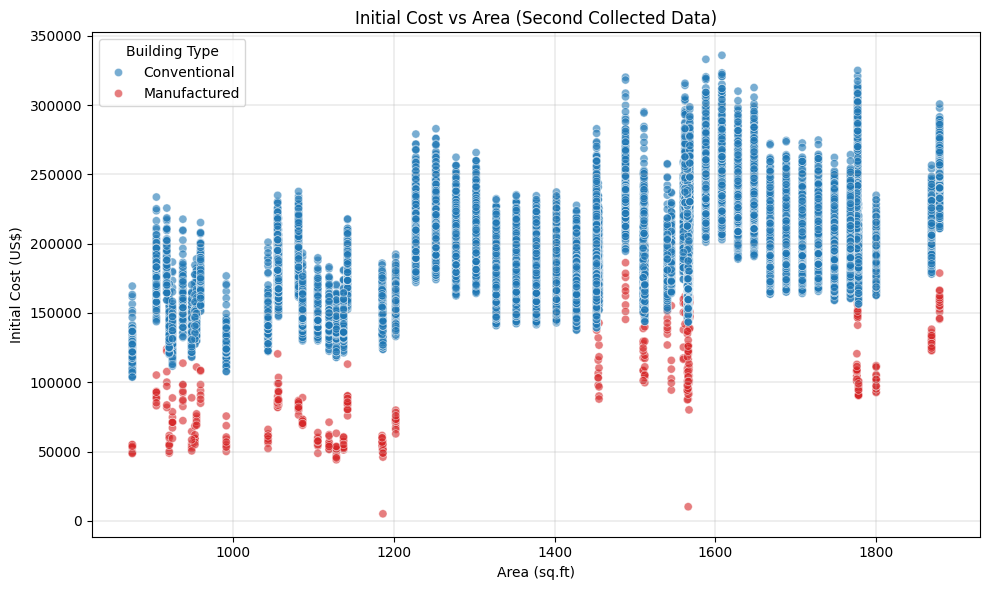

Saved to: E:\PhD Related Documents\Codes\ml_projects\lcc\New Figures


In [4]:
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Create plotting label (Modular -> Manufactured) ----
df["Type_label"] = (
    df["Type"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({"Modular": "Manufactured"})
)

hue_order = ["Conventional", "Manufactured"]

palette = {
    "Conventional": "#1f77b4",   # deep blue
    "Manufactured": "#d62728"    # strong red
}

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Area",
    y="Initial Cost",
    hue="Type_label",
    hue_order=hue_order,
    palette=palette,
    alpha=0.6,
    s=35
)

plt.title("Initial Cost vs Area (Second Collected Data)")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Initial Cost (US$)")
plt.grid(True, linewidth=0.3)
plt.legend(title="Building Type")
plt.tight_layout()

# ---- Save to New Figures folder ----
base_dir = Path(r"E:\PhD Related Documents\Codes\ml_projects\lcc")
out_dir = base_dir / "New Figures"
out_dir.mkdir(exist_ok=True)

plt.savefig(out_dir / "second_collected_data.png", dpi=600, bbox_inches="tight")
plt.savefig(out_dir / "second_collected_data.pdf", bbox_inches="tight")

plt.show()

print("Saved to:", out_dir)

***Correlation Matrix***

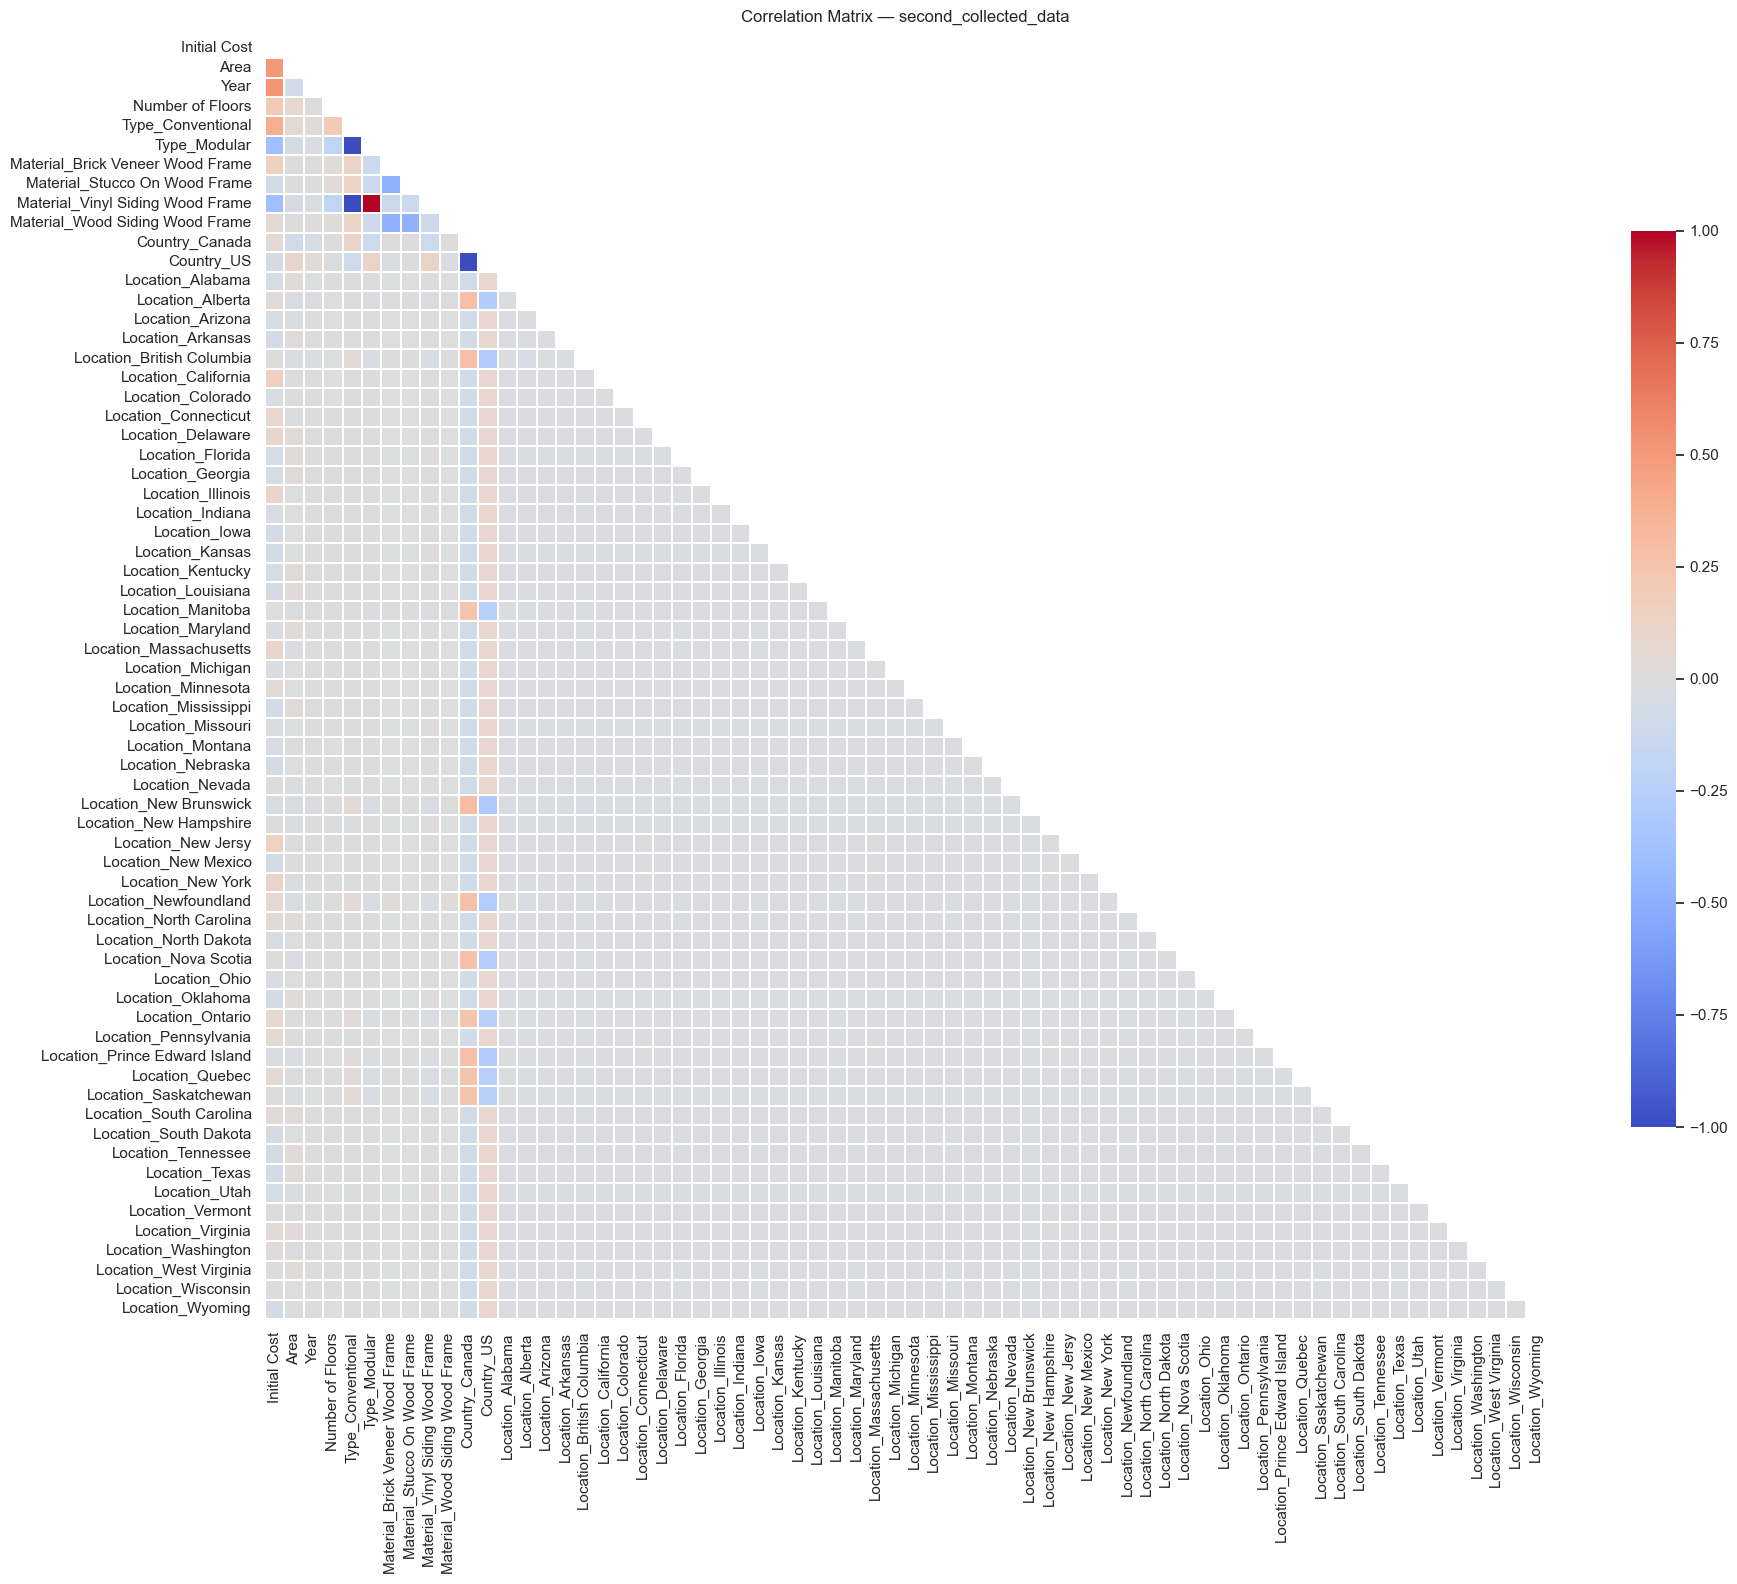


Data types used:
 Initial Cost        float64
Area                  int64
Year                  int64
Number of Floors    float64
Type                 object
Material             object
Country              object
Location             object
dtype: object

Top correlations with Initial Cost (abs, top 10):
Year                                0.525047
Area                                0.503827
Type_Modular                        0.395428
Material_Vinyl Siding Wood Frame    0.395428
Type_Conventional                   0.395428
Number of Floors                    0.205190
Location_California                 0.157145
Material_Brick Veneer Wood Frame    0.156834
Location_New Jersy                  0.142639
Location_New York                   0.114081
Name: Initial Cost, dtype: float64


In [6]:
# correlation_matrix_first_collected_data.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -----------------------------
# 0) Config
# -----------------------------
CSV_PATH = "second_collected_data.csv"   # change if needed

NUM_COLS   = ["Initial Cost", "Area", "Year", "Number of Floors"]
CAT_COLS   = ["Type", "Material", "Country", "Location"]

# -----------------------------
# 1) Load & clean
# -----------------------------
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# common alternate header seen in your files
if "Type of Building" in df.columns and "Type" not in df.columns:
    df = df.rename(columns={"Type of Building": "Type"})

# trim string columns if present
for c in CAT_COLS:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# numeric coercion (remove $, commas, spaces, etc.)
def to_num(s):
    s = pd.Series(s).astype(str)
    s = s.str.replace(r"[^0-9.\-eE]", "", regex=True)  # keep digits, ., -, scientific notation
    return pd.to_numeric(s, errors="coerce")

for c in NUM_COLS:
    if c in df.columns:
        df[c] = to_num(df[c])

# keep rows that have at least Area & Initial Cost for sanity
need = [c for c in ["Area", "Initial Cost"] if c in df.columns]
if need:
    df = df.dropna(subset=need).reset_index(drop=True)

# -----------------------------
# 2) Build the matrix data
# -----------------------------
# keep only columns that exist
use_num = [c for c in NUM_COLS if c in df.columns]
use_cat = [c for c in CAT_COLS if c in df.columns]

if not use_num:
    raise ValueError("No numeric columns found among: " + ", ".join(NUM_COLS))

# One-hot encode categoricals (don’t drop first so you see full relationships)
df_enc = pd.get_dummies(
    df[use_num + use_cat],
    columns=use_cat,
    drop_first=False,
    dtype=float
)

# Optional: if you have *many* categories, the matrix can get huge.
# You can uncomment the next line to drop near-constant columns:
# df_enc = df_enc.loc[:, df_enc.nunique() > 1]

corr = df_enc.corr()

# -----------------------------
# 3) Plot — Seaborn heatmap (upper triangle)
# -----------------------------
sns.set_theme(context="notebook", style="white")

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

# If the matrix is very large, turn off annotations
annot = corr.shape[0] <= 25

plt.figure(figsize=(min(1.0*corr.shape[0], 20), min(0.8*corr.shape[0], 16)))
ax = sns.heatmap(
    corr, mask=mask, vmin=-1, vmax=1, center=0,
    cmap="coolwarm", square=True, linewidths=0.2,
    cbar_kws={"shrink": 0.7},
    annot=annot, fmt=".2f" if annot else ""
)
plt.title("Correlation Matrix — second_collected_data", pad=12)
plt.tight_layout()
plt.show()

# -----------------------------
# 4) (Optional) print quick summaries
# -----------------------------
print("\nData types used:\n", df[use_num + use_cat].dtypes)
print("\nTop correlations with Initial Cost (abs, top 10):")
if "Initial Cost" in corr.columns:
    target_corr = corr["Initial Cost"].drop(labels=["Initial Cost"], errors="ignore").abs().sort_values(ascending=False)
    print(target_corr.head(10))


***Cost vs Location vs Material***

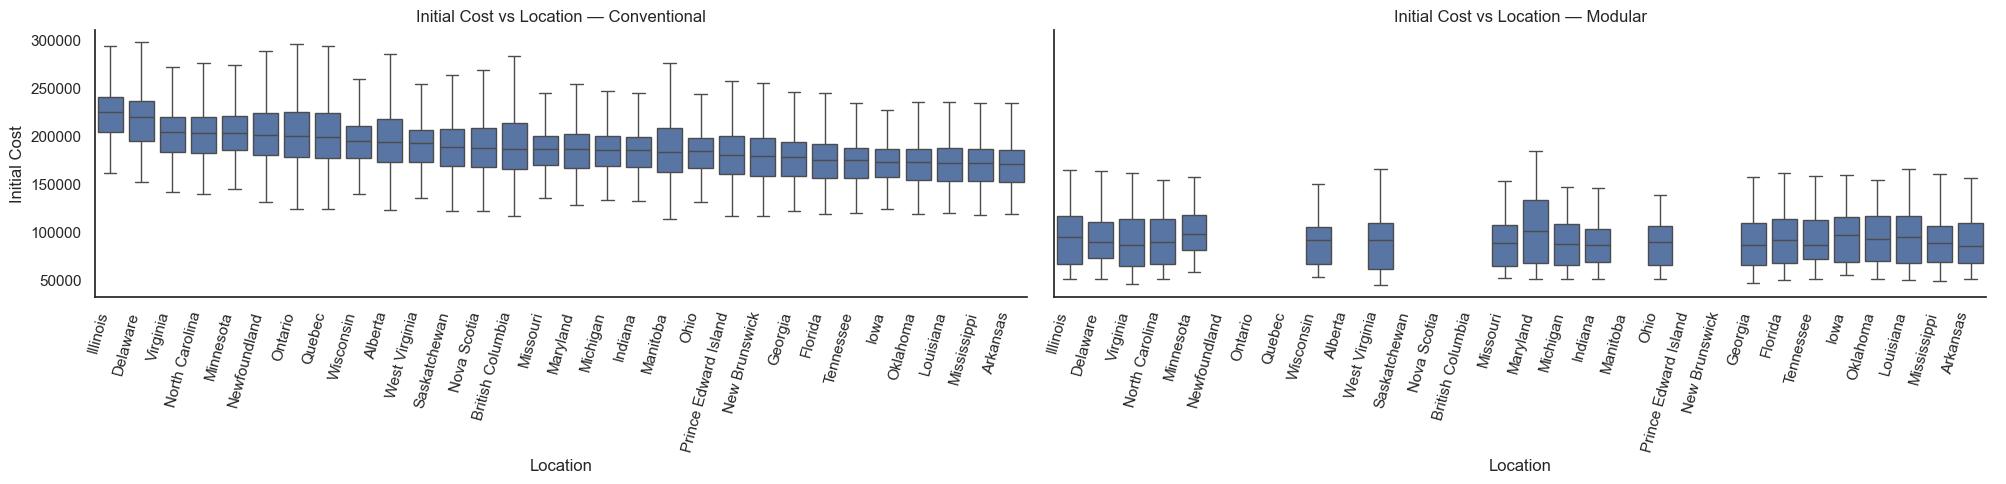

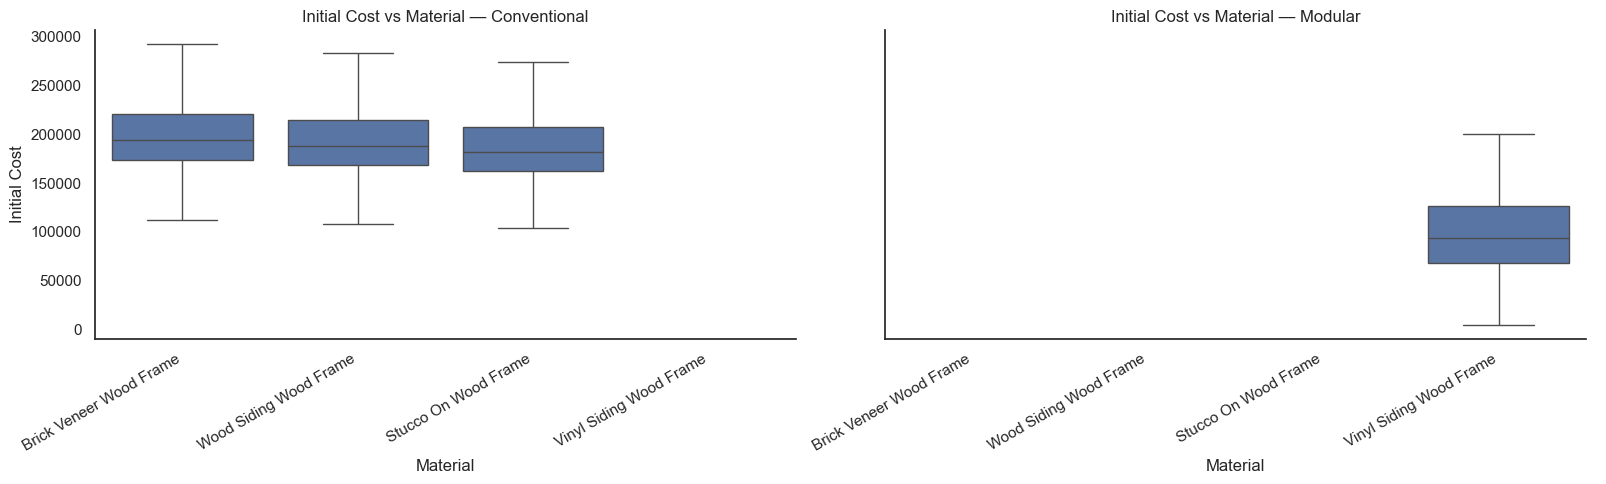

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = "second_collected_data.csv"
df = pd.read_csv(path)
df.columns = df.columns.str.strip()

# ---- Clean strings ----
for c in ["Type","Location","Material","Country"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Normalize labels
df["Type"] = df["Type"].str.capitalize()
df["Location"] = df["Location"].str.title()
df["Material"] = df["Material"].str.title()

# ---- Robust numeric coercion (handles $ and commas) ----
def to_num(s):
    return pd.to_numeric(
        pd.Series(s).astype(str).str.replace(r"[^0-9.\-eE]", "", regex=True),
        errors="coerce"
    )

for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = to_num(df[c])

# Keep rows with cost
df = df.dropna(subset=["Initial Cost"]).copy()

# Facet order
col_order = ["Conventional", "Modular"]

# ---------- Cost vs Location ----------
top_n = 30
# drop missing x var and keep only top-N by count
df_loc = df.dropna(subset=["Location"]).copy()
top_locations = df_loc["Location"].value_counts().nlargest(top_n).index
df_loc = df_loc[df_loc["Location"].isin(top_locations)].copy()

# order locations by median cost (more informative than alphabetical)
loc_order = (
    df_loc.groupby("Location")["Initial Cost"]
    .median()
    .sort_values(ascending=False)
    .index
)

g = sns.catplot(
    data=df_loc, x="Location", y="Initial Cost", col="Type",
    col_order=[t for t in col_order if t in df_loc["Type"].unique()],
    order=loc_order,
    kind="box", sharey=True, showfliers=False, height=5, aspect=2
)
g.set_xticklabels(rotation=75, ha="right")
g.set_titles("Initial Cost vs Location — {col_name}")
plt.tight_layout()
plt.show()

# ---------- Cost vs Material ----------
top_n_mat = 10
df_mat = df.dropna(subset=["Material"]).copy()
top_materials = df_mat["Material"].value_counts().nlargest(top_n_mat).index
df_mat = df_mat[df_mat["Material"].isin(top_materials)].copy()

mat_order = (
    df_mat.groupby("Material")["Initial Cost"]
    .median()
    .sort_values(ascending=False)
    .index
)

g = sns.catplot(
    data=df_mat, x="Material", y="Initial Cost", col="Type",
    col_order=[t for t in col_order if t in df_mat["Type"].unique()],
    order=mat_order,
    kind="box", sharey=True, showfliers=False, height=5, aspect=1.6
)
g.set_xticklabels(rotation=30, ha="right")
g.set_titles("Initial Cost vs Material — {col_name}")
plt.tight_layout()
plt.show()


***Cost vs Year vs Type***

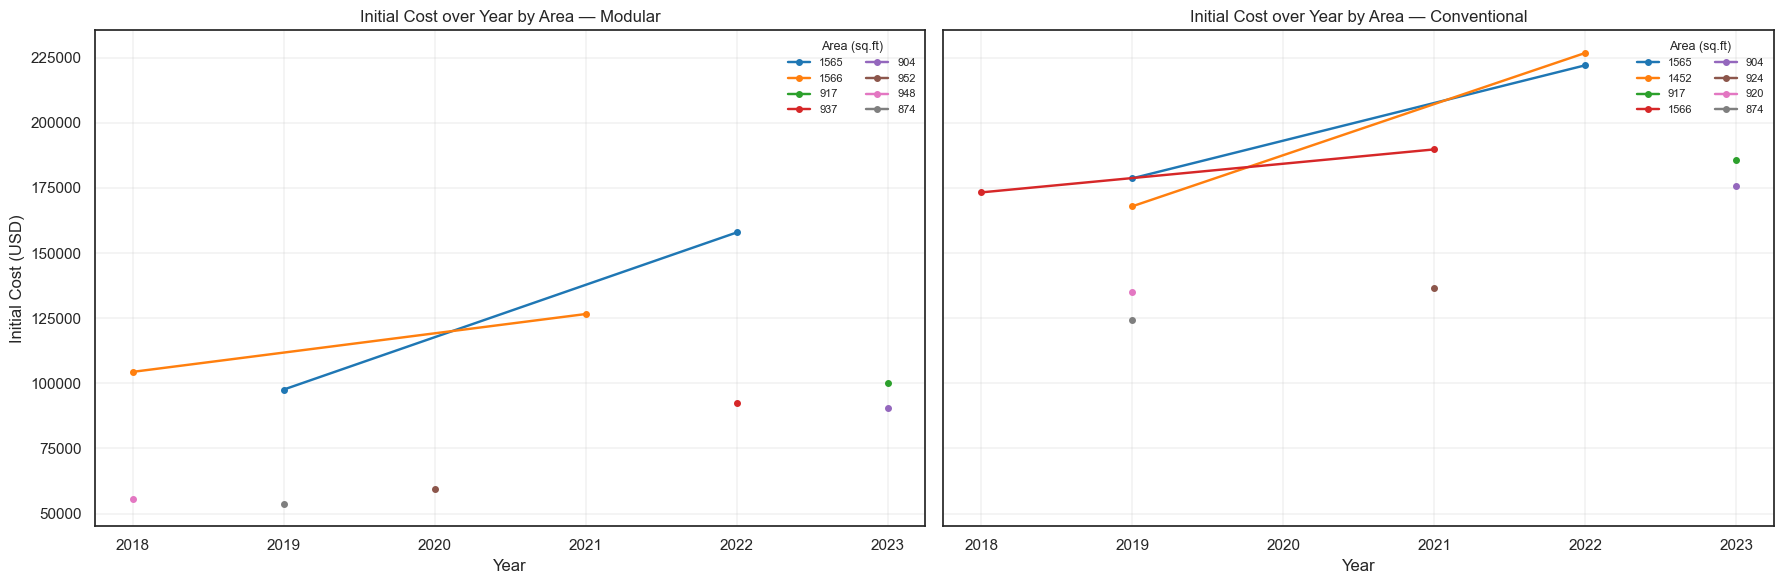

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Load & basic clean
# ---------------------------
path = "second_collected_data.csv"
df = pd.read_csv(path)
df.columns = df.columns.str.strip()

# numeric coercion
for c in ["Area", "Year", "Number of Floors", "Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# normalize type
df["Type"] = df["Type"].astype(str).str.strip().str.capitalize()

# keep essentials
df = df.dropna(subset=["Area", "Year", "Initial Cost", "Type"]).copy()
df["Year"] = df["Year"].round().astype(int)

# ---------------------------
# Aggregate without interpolation
# ---------------------------
agg = (
    df.groupby(["Type", "Area", "Year"], as_index=False)["Initial Cost"]
      .median()   # use .mean() if you prefer
      .sort_values(["Type", "Area", "Year"])
)

# choose representative areas: by number of records across years
TOP_N = 8
area_counts = (
    agg.groupby(["Type", "Area"])["Year"]
       .count()
       .rename("n_points")
       .reset_index()
)

def plot_panel(ax, t, cmap_name="tab10"):
    ac = area_counts[area_counts["Type"] == t].sort_values("n_points", ascending=False)
    top_areas = ac["Area"].head(TOP_N).tolist()
    dat_t = agg[(agg["Type"] == t) & (agg["Area"].isin(top_areas))].copy()

    if dat_t.empty:
        ax.set_title(f"Initial Cost over Year by Area — {t} (no data)")
        ax.grid(True, linewidth=0.3)
        return

    # stable color cycle
    cmap = plt.get_cmap(cmap_name)
    lines = []
    for a in sorted(top_areas):
        sub = dat_t[dat_t["Area"] == a].sort_values("Year")
        if sub.empty:
            continue
        lines.append((a, sub))

    # optional: order legend by median cost (descending)
    lines.sort(key=lambda x: np.nanmedian(x[1]["Initial Cost"]), reverse=True)

    for i, (a, sub) in enumerate(lines):
        ax.plot(
            sub["Year"], sub["Initial Cost"],
            marker="o", linewidth=1.75, markersize=4,
            label=f"{int(a)}", color=cmap(i % max(10, len(lines)))
        )

    ax.set_title(f"Initial Cost over Year by Area — {t}")
    ax.set_xlabel("Year")
    ax.grid(True, linewidth=0.3)
    if t == "Modular":
        ax.set_ylabel("Initial Cost (USD)")
    else:
        ax.set_ylabel("")
    ax.legend(title="Area (sq.ft)", fontsize=8, title_fontsize=9, ncol=2, frameon=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, t in zip(axes, ["Modular", "Conventional"]):
    plot_panel(ax, t)

plt.tight_layout()
plt.show()


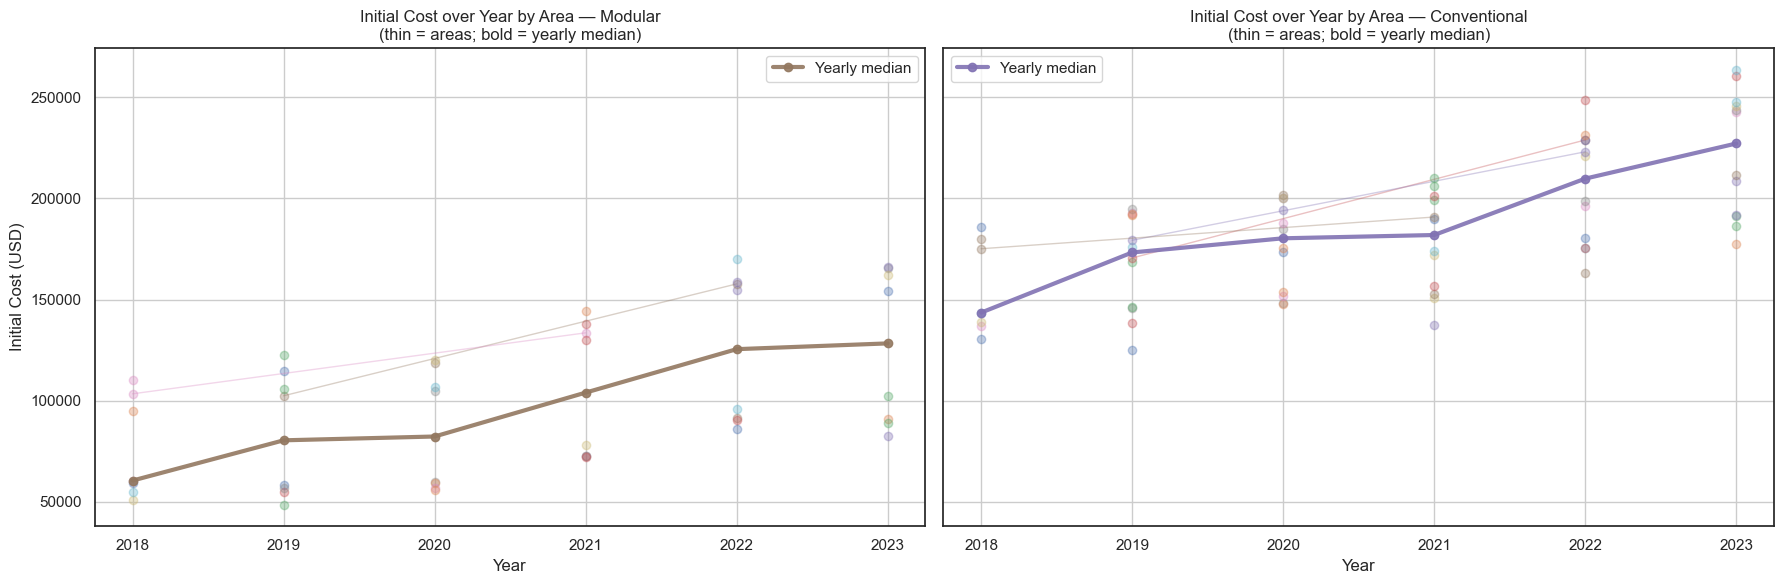

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
path = "second_collected_data.csv"   # or "/mnt/data/first_collected_data.csv"
df = pd.read_csv(path)
df.columns = df.columns.str.strip()

# Clean types & numerics
df["Type"] = df["Type"].astype(str).str.strip().str.capitalize()
for c in ["Area", "Year", "Number of Floors", "Initial Cost"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["Area","Year","Initial Cost","Type"]).copy()

# Keep all areas that have data in >= 2 different years (so we can draw a line)
def prep(df, t):
    dft = df[df["Type"] == t].copy()
    areas_to_keep = dft.groupby("Area")["Year"].nunique()
    areas_to_keep = areas_to_keep[areas_to_keep >= 1].index
    dft = dft[dft["Area"].isin(areas_to_keep)]
    # aggregate duplicates (same Area-Year) with mean
    dft = (dft.groupby(["Area","Year"], as_index=False)["Initial Cost"]
              .mean()
              .sort_values(["Area","Year"]))
    return dft

mod = prep(df, "Modular")
conv = prep(df, "Conventional")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

def plot_many(ax, data, title):
    # thin transparent lines: each area
    for a, sub in data.groupby("Area"):
        ax.plot(sub["Year"], sub["Initial Cost"], marker="o", linewidth=1, alpha=0.35)
    # bold median trend across areas per year
    med = (data.groupby("Year")["Initial Cost"].median()
                 .reset_index()
                 .sort_values("Year"))
    ax.plot(med["Year"], med["Initial Cost"], marker="o", linewidth=3,
            alpha=0.9, label="Yearly median")

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Initial Cost (USD)")
    ax.grid(True)
    ax.legend(loc="best")

    # ✅ Force ticks to match only the actual dataset years
    years = sorted(data["Year"].unique())
    ax.set_xticks(years)
    ax.set_xticklabels(years)



plot_many(axes[0], mod, "Initial Cost over Year by Area — Modular\n(thin = areas; bold = yearly median)")
plot_many(axes[1], conv, "Initial Cost over Year by Area — Conventional\n(thin = areas; bold = yearly median)")

axes[0].set_ylabel("Initial Cost (USD)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


***Principal Component Analysis (PCA)***

Expanded feature count: 65
Full PCA components: 65
PCA(0.95) components: 43


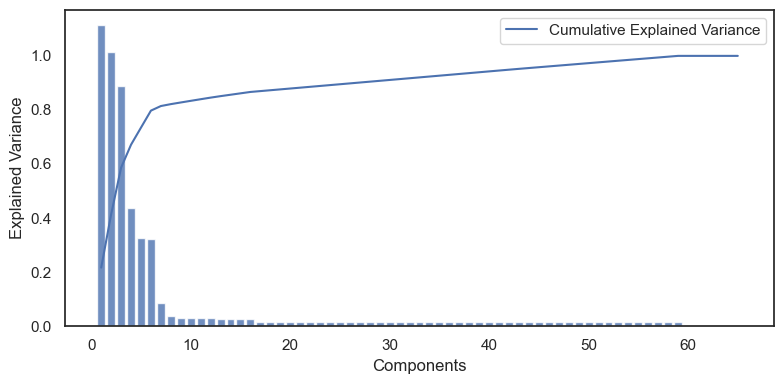

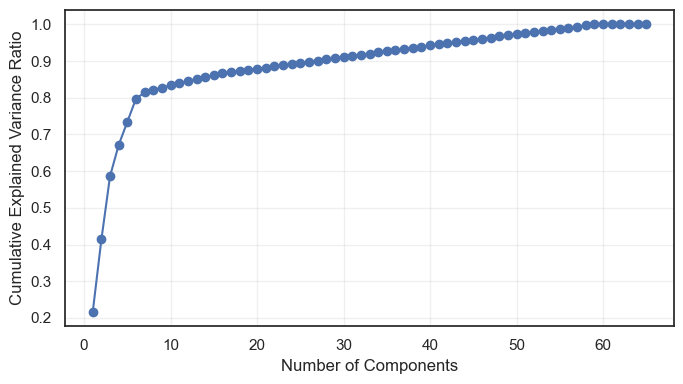


Top features for PC1:
Area                                0.727120
Number of Floors                    0.499501
Country_US                          0.026130
Type_Conventional                   0.020929
Material_Stucco On Wood Frame       0.007985
Material_Brick Veneer Wood Frame    0.006628
Material_Wood Siding Wood Frame     0.006315
Location_Alabama                    0.003252
Location_Delaware                   0.002637
Location_Tennessee                  0.002637
Name: PC1, dtype: float64


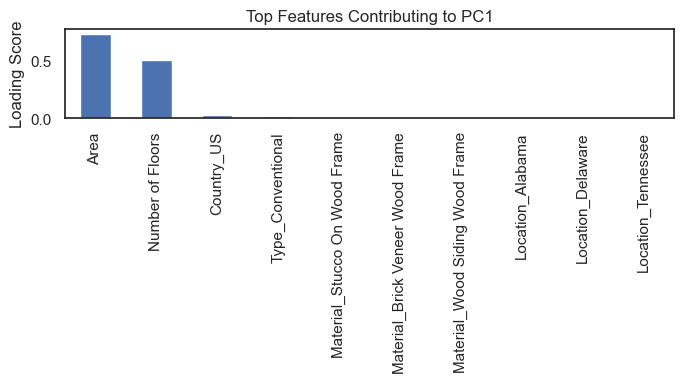


Top features for PC2:
Year                                0.720343
Number of Floors                    0.691128
Type_Conventional                   0.028172
Country_US                          0.016130
Material_Stucco On Wood Frame       0.010883
Material_Wood Siding Wood Frame     0.008664
Material_Brick Veneer Wood Frame    0.008626
Location_Michigan                   0.000659
Location_Wisconsin                  0.000659
Location_Minnesota                  0.000659
Name: PC2, dtype: float64


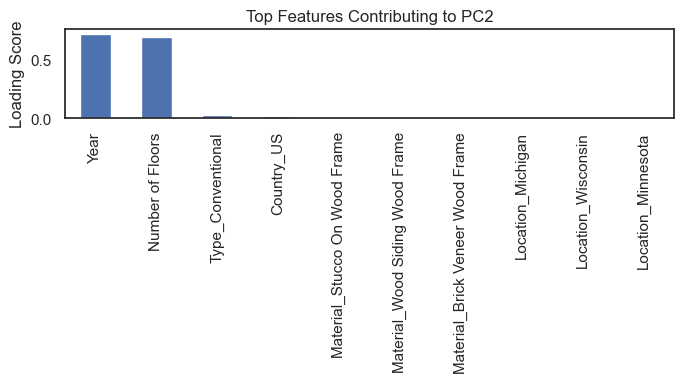

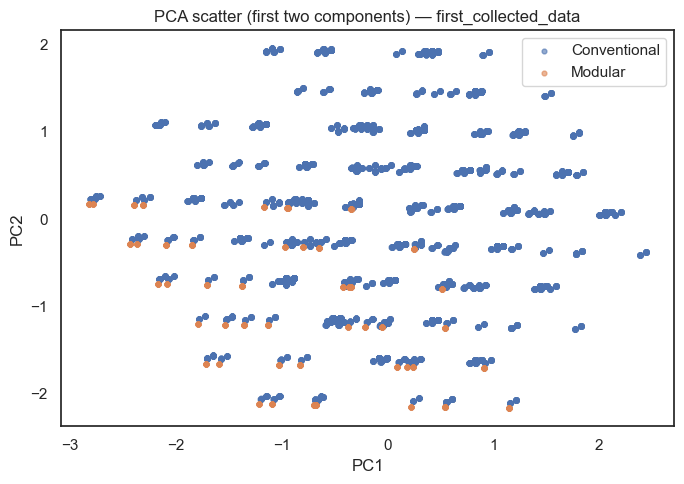

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# 1) Load & tidy (current dataset)
# -----------------------------
PATH = "second_collected_data.csv"   # or "/mnt/data/first_collected_data.csv"
df = pd.read_csv(PATH)
df.columns = df.columns.str.strip()

# keep columns (guard for availability)
cols = ["Type","Area","Year","Location","Country","Number of Floors","Material","Initial Cost"]
cols = [c for c in cols if c in df.columns]
df = df[cols].copy()

# numerics
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# strings
for c in ["Type","Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# essential predictors
essential = [c for c in ["Area","Year","Number of Floors","Type","Location","Country","Material"] if c in df.columns]
df = df.dropna(subset=essential).reset_index(drop=True)

# -----------------------------
# 2) Build X (features only)
# -----------------------------
cat_features = [c for c in ["Type","Location","Country","Material"] if c in df.columns]
num_features = [c for c in ["Area","Year","Number of Floors"] if c in df.columns]
X_df = df[cat_features + num_features].copy()

# -----------------------------
# 3) Preprocess (OneHot + Scale) and PCA
#    -> compatible with both new/old sklearn (sparse_output vs sparse)
# -----------------------------
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)         # older sklearn

ct = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_features),
        ("num", StandardScaler(), num_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_mat = ct.fit_transform(X_df)
feature_names = ct.get_feature_names_out()

# PCA (full) + PCA(95%)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_mat)

pca95 = PCA(0.95)
X_pca95 = pca95.fit_transform(X_mat)
print("Expanded feature count:", len(feature_names))
print("Full PCA components:", pca_full.n_components_)
print("PCA(0.95) components:", pca95.n_components_)

# -----------------------------
# 4) Explained variance plots
# -----------------------------
plt.figure(figsize=(8,4))
plt.bar(range(1, len(pca_full.explained_variance_) + 1), pca_full.explained_variance_, alpha=0.8)
plt.plot(range(1, len(pca_full.explained_variance_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), label="Cumulative Explained Variance")
plt.xlabel("Components"); plt.ylabel("Explained Variance")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components"); plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Loadings (feature contributions)
# -----------------------------
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_full.components_.shape[0])],
    index=feature_names
)

print("\nTop features for PC1:")
print(loadings["PC1"].sort_values(ascending=False).head(10))

plt.figure(figsize=(7,4))
loadings["PC1"].sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Features Contributing to PC1"); plt.ylabel("Loading Score")
plt.tight_layout(); plt.show()

print("\nTop features for PC2:")
print(loadings["PC2"].sort_values(ascending=False).head(10))

plt.figure(figsize=(7,4))
loadings["PC2"].sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Features Contributing to PC2"); plt.ylabel("Loading Score")
plt.tight_layout(); plt.show()

# -----------------------------
# 6) 2D scatter of first two PCs (colored by Type)
# -----------------------------
if "Type" in df.columns:
    pc_df = pd.DataFrame(X_pca_full[:, :2], columns=["PC1","PC2"])
    pc_df["Type"] = df["Type"].values
    plt.figure(figsize=(7,5))
    for t, g in pc_df.groupby("Type"):
        plt.scatter(g["PC1"], g["PC2"], s=12, alpha=0.6, label=t)
    plt.legend(); plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.title("PCA scatter (first two components) — first_collected_data")
    plt.tight_layout(); plt.show()


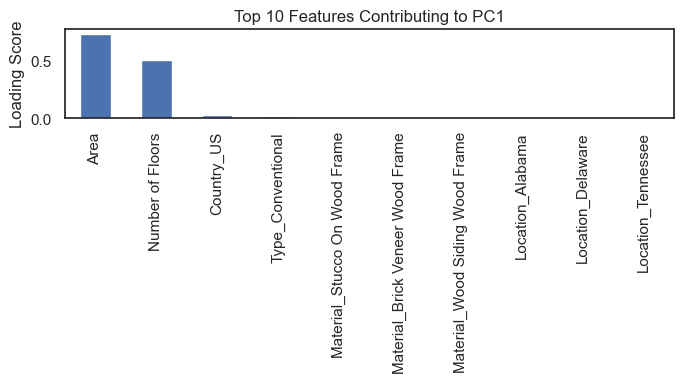

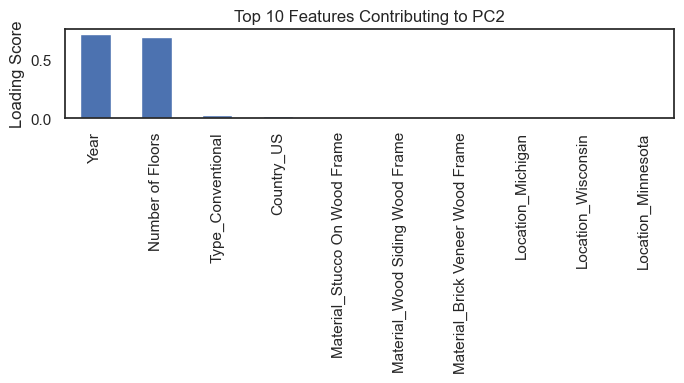

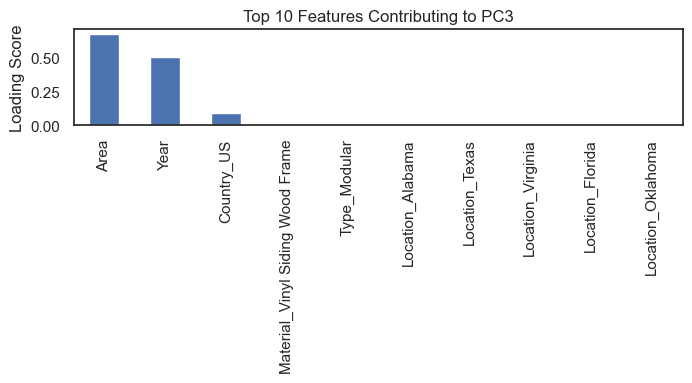

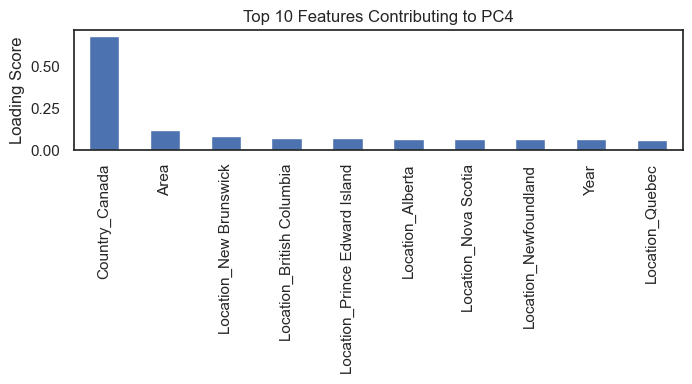

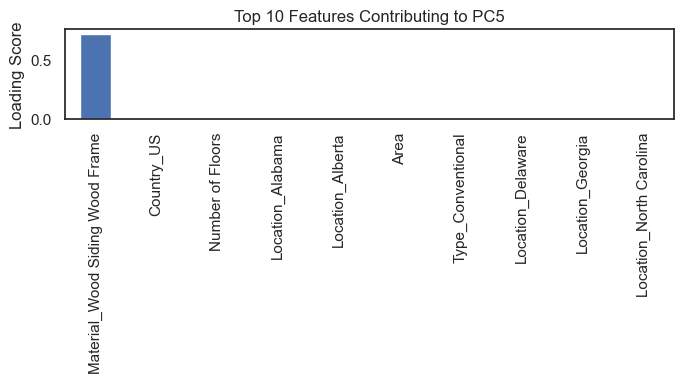

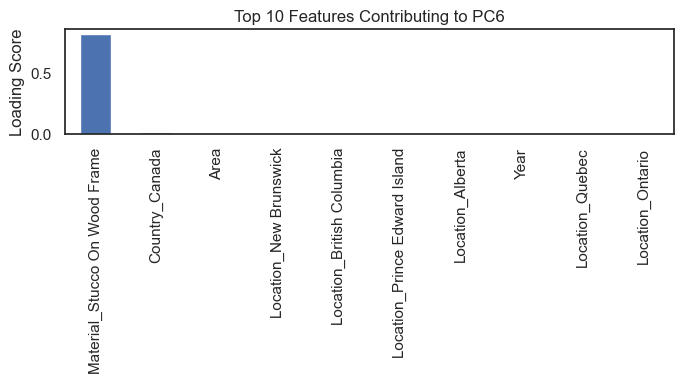

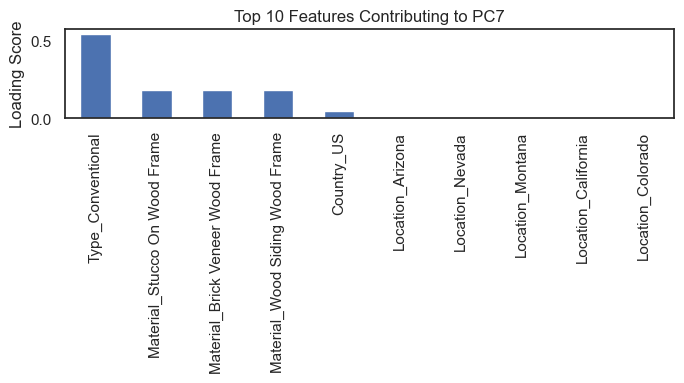

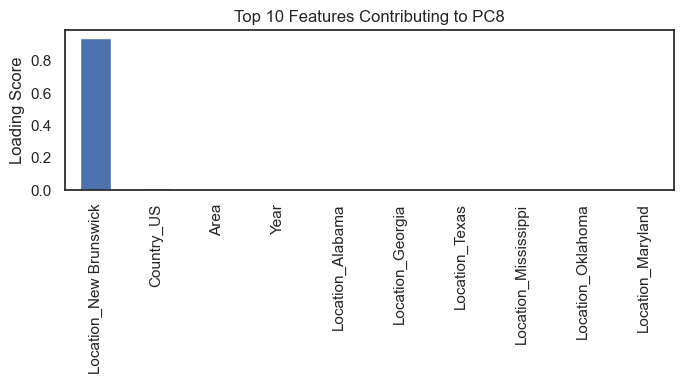

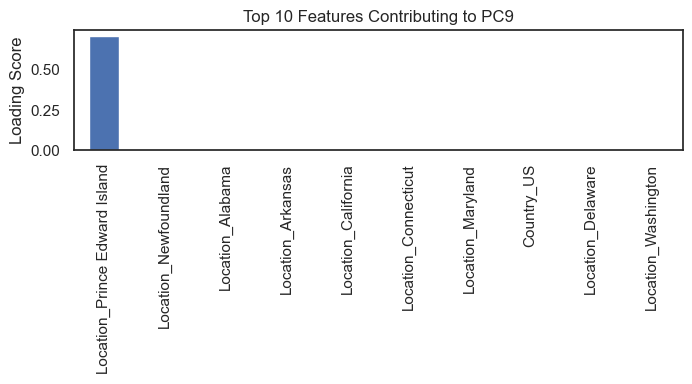

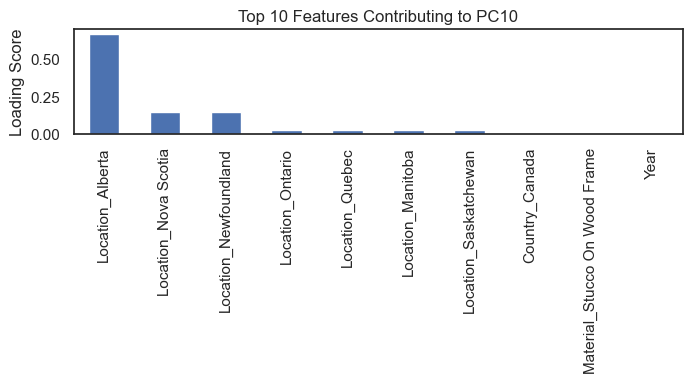

In [11]:
# -----------------------------
# Plot top features up to PC10
# -----------------------------
top_k_pcs = min(10, loadings.shape[1])  # up to 10 PCs or as many as available

for i in range(top_k_pcs):
    pc = f"PC{i+1}"
    top_feats = loadings[pc].sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(7,4))
    top_feats.plot(kind="bar")
    plt.title(f"Top 10 Features Contributing to {pc}")
    plt.ylabel("Loading Score")
    plt.tight_layout()
    plt.show()


***Training Machine Learning Model***

In [15]:
import pandas as pd, numpy as np, json, joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error

# ----------------------------
# Paths
# ----------------------------
SECOND_DATA_PATH   = "second_collected_data.csv"     # change if needed
SECOND_METRICS_PATH = "ensemble_cv_summary_secondcollected.csv"
SECOND_MODEL_PATH   = "best_auto_model_secondcollected.joblib"
SECOND_SPEC_PATH    = "auto_model_spec_secondcollected.json"

# ----------------------------
# Load + tidy
# ----------------------------
df = pd.read_csv(SECOND_DATA_PATH)
df.columns = df.columns.str.strip().str.replace(r"\s+$","", regex=True)

# harmonize common trailing-space column names if present
rename_map = {
    "Type of Building":"Type",
    "Initial Cost ":"Initial Cost",
    "Area ":"Area",
}
df = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})

needed_X = ["Type","Area","Year","Location","Country","Number of Floors","Material"]
target   = "Initial Cost"

# keep only available columns
have_X = [c for c in needed_X if c in df.columns]
if target not in df.columns:
    raise ValueError(f'"{target}" column not found in {DATA_PATH}')

# basic cleaning
for c in ["Type","Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows with missing core fields
df = df.dropna(subset=have_X + [target]).reset_index(drop=True)

X = df[have_X].copy()
y = df[target].values

# ----------------------------
# Preprocessors
#   - separate OHEs so no shared fit state
#   - SVR gets MinMax on numerics (common for SVR)
#   - Handle sklearn versions with/without 'sparse_output'
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)         # older versions

cat_cols = [c for c in ["Type","Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

ohe_lr_rf = make_ohe()
ohe_svr   = make_ohe()

pre_lr_rf = ColumnTransformer(
    [("cat", ohe_lr_rf, cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

pre_svr = ColumnTransformer(
    [("cat", ohe_svr, cat_cols),
     ("num", MinMaxScaler(), num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

# ----------------------------
# Models
# ----------------------------
models = {
    "Linear Regression": Pipeline([("pre", pre_lr_rf),
                                   ("model", LinearRegression())]),
    "SVR (Linear, C=1000)": Pipeline([("pre", pre_svr),
                                      ("model", SVR(kernel="linear", C=1000, epsilon=0.1))]),
    "Random Forest": Pipeline([("pre", pre_lr_rf),
                               ("model", RandomForestRegressor(
                                   n_estimators=400, random_state=42, n_jobs=-1
                               ))]),
}

# ----------------------------
# Cross-validation & scoring
# ----------------------------
n_splits = max(2, min(5, len(X)))  # robust for small datasets
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

scorers = {
    "r2":   make_scorer(r2_score),
    "mae":  make_scorer(mean_absolute_error, greater_is_better=False),
    "rmse": make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
                        greater_is_better=False),
}

rows = []
for name, pipe in models.items():
    cv = cross_validate(pipe, X, y, cv=kf, scoring=scorers, n_jobs=-1)
    rows.append({
        "Model": name,
        "R2_mean":   float(np.mean(cv["test_r2"])),
        "R2_std":    float(np.std(cv["test_r2"])),
        "MAE_mean":  float(-np.mean(cv["test_mae"])),
        "MAE_std":   float(np.std(-cv["test_mae"])),
        "RMSE_mean": float(-np.mean(cv["test_rmse"])),
        "RMSE_std":  float(np.std(-cv["test_rmse"])),
    })

cv_df = pd.DataFrame(rows).sort_values("RMSE_mean").reset_index(drop=True)
cv_df.to_csv(SECOND_METRICS_PATH, index=False)

# ----------------------------
# Choose & save best model
# ----------------------------
best_name = cv_df.iloc[0]["Model"]
best_pipe = models[best_name].fit(X, y)
joblib.dump(best_pipe, SECOND_MODEL_PATH)

with open(SECOND_SPEC_PATH, "w") as f:
    json.dump({
        "chosen_model": best_name,
        "metrics_table": SECOND_METRICS_PATH,
        "model_path": SECOND_MODEL_PATH,
        "features_used": have_X,
        "target": target,
        "cv_folds": n_splits
    }, f, indent=2)

# ----------------------------
# Print leaderboard
# ----------------------------
print("\nCross-validated leaderboard (sorted by RMSE):")
print(cv_df.round({
    "R2_mean": 4, "R2_std": 4, "MAE_mean": 2, "MAE_std": 2, "RMSE_mean": 2, "RMSE_std": 2
}))
print(f"\nChosen: {best_name}")
print("Saved metrics ->", SECOND_METRICS_PATH)
print("Saved model   ->", SECOND_MODEL_PATH)
print("Spec JSON     ->", SECOND_SPEC_PATH)



Cross-validated leaderboard (sorted by RMSE):
                  Model  R2_mean  R2_std  MAE_mean  MAE_std  RMSE_mean  \
0         Random Forest   0.9894  0.0006   2576.20    43.58    4013.15   
1     Linear Regression   0.9271  0.0040   7798.67    88.62   10538.91   
2  SVR (Linear, C=1000)   0.9259  0.0035   7785.07    63.93   10622.68   

   RMSE_std  
0    134.80  
1    182.34  
2    147.27  

Chosen: Random Forest
Saved metrics -> ensemble_cv_summary_secondcollected.csv
Saved model   -> best_auto_model_secondcollected.joblib
Spec JSON     -> auto_model_spec_secondcollected.json


***Predicted vs Actual Cost Graph***

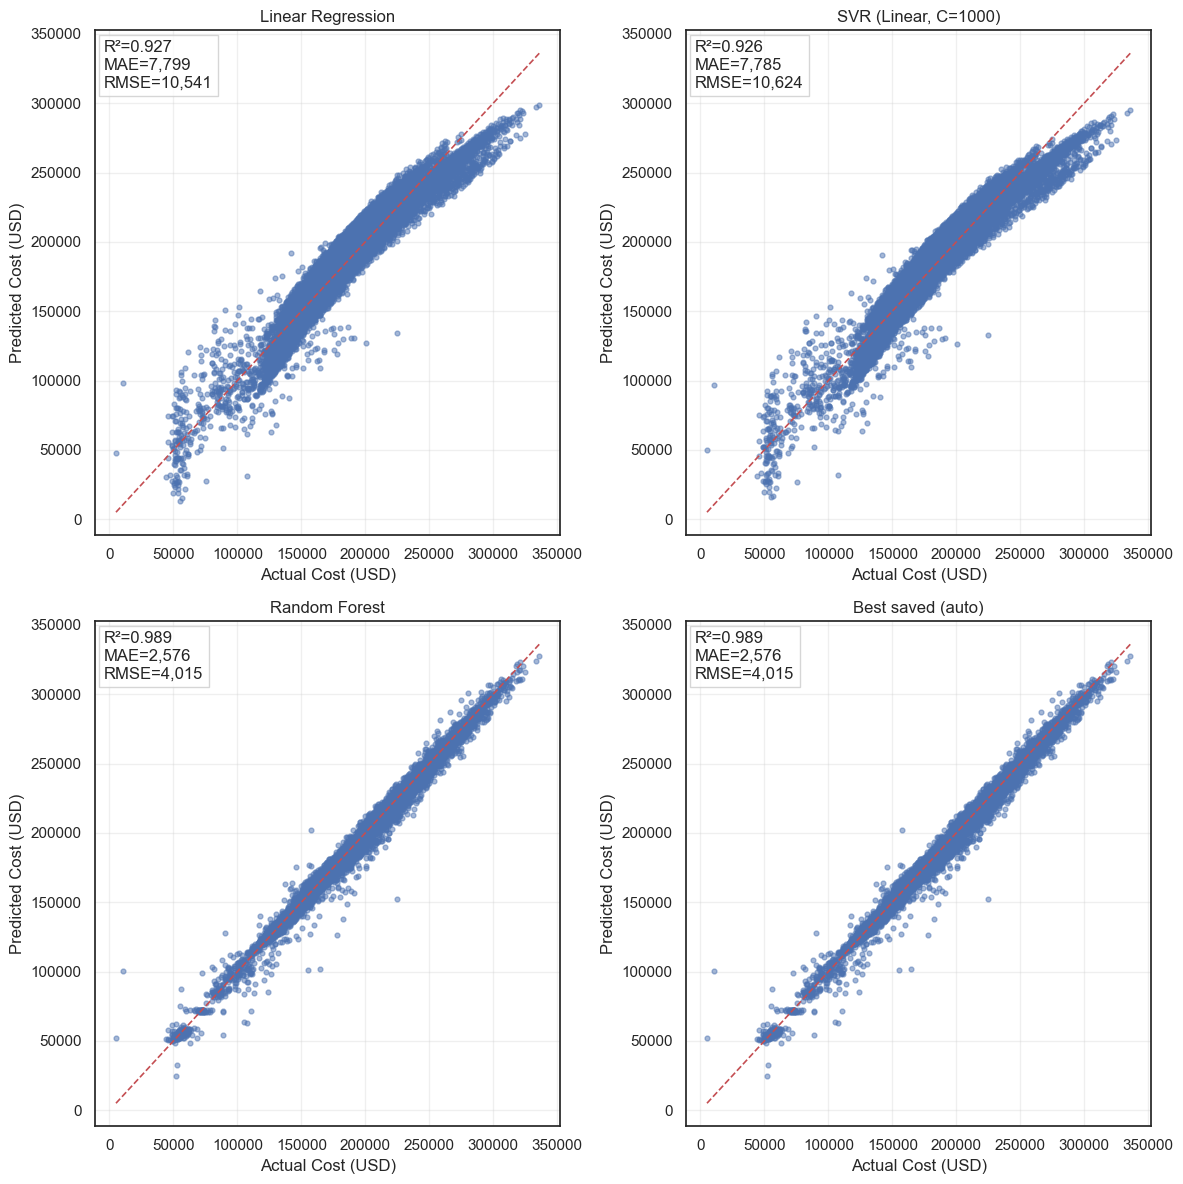

In [16]:
import pandas as pd, numpy as np, joblib, json, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SECOND_DATA_PATH  = "second_collected_data.csv"
SECOND_MODEL_PATH = "best_auto_model_secondcollected.joblib"

# ----------------------------
# Load & tidy
# ----------------------------
df = pd.read_csv(SECOND_DATA_PATH)
df.columns = df.columns.str.strip().str.replace(r"\s+$","", regex=True)
# normalize possible legacy column names
df = df.rename(columns={
    "Type of Building":"Type",
    "Initial Cost ":"Initial Cost",
    "Area ":"Area",
})

# clean types
for c in ["Type","Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()
# numerics
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# features/target
feat_cols = [c for c in ["Type","Area","Year","Location","Country","Number of Floors","Material"] if c in df.columns]
target = "Initial Cost"
df = df.dropna(subset=feat_cols + [target]).reset_index(drop=True)

X = df[feat_cols].copy()
y = df[target].values

# ----------------------------
# Preprocessors (handle sklearn versions)
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >=1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)         # older

cat_cols = [c for c in ["Type","Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

ohe_lr_rf = make_ohe()
ohe_svr   = make_ohe()

pre_lr_rf = ColumnTransformer(
    [("cat", ohe_lr_rf, cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

pre_svr = ColumnTransformer(
    [("cat", ohe_svr, cat_cols),
     ("num", MinMaxScaler(), num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

# ----------------------------
# Models + load your saved best pipeline
# ----------------------------
models = {
    "Linear Regression": Pipeline([("pre", pre_lr_rf), ("model", LinearRegression())]),
    "SVR (Linear, C=1000)": Pipeline([("pre", pre_svr), ("model", SVR(kernel="linear", C=1000, epsilon=0.1))]),
    "Random Forest": Pipeline([("pre", pre_lr_rf), ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))]),
}

# add saved best (already a full pipeline with preprocessor inside)
best_pipe = joblib.load(SECOND_MODEL_PATH)
models["Best saved (auto)"] = best_pipe

# ----------------------------
# CV setup
# ----------------------------
n_splits = max(2, min(5, len(X)))  # robust if dataset is small
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

def metrics_text(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return f"R²={r2:0.3f}\nMAE={mae:,.0f}\nRMSE={rmse:,.0f}"

# ----------------------------
# Plot Actual vs Predicted (OOF) for 4 models
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for ax, (name, pipe) in zip(axes, models.items()):
    y_oof = cross_val_predict(pipe, X, y, cv=kf, n_jobs=-1)
    ax.scatter(y, y_oof, s=12, alpha=0.5)
    lo, hi = float(np.min(y)), float(np.max(y))
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2, label="Perfect prediction")
    ax.set_title(name)
    ax.set_xlabel("Actual Cost (USD)")
    ax.set_ylabel("Predicted Cost (USD)")
    ax.text(0.02, 0.98, metrics_text(y, y_oof),
            transform=ax.transAxes, va="top", ha="left",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="0.8"))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


***Overfitting Check (K-Fold)***


Linear Regression
  Fold 1: R2=0.9243, MAE=7,792, RMSE=10,522
  Fold 2: R2=0.9215, MAE=7,959, RMSE=10,887
  Fold 3: R2=0.9269, MAE=7,691, RMSE=10,478
  Fold 4: R2=0.9327, MAE=7,757, RMSE=10,355
  Fold 5: R2=0.9298, MAE=7,794, RMSE=10,453
  Avg   : R2=0.9271, MAE=7,799, RMSE=10,539


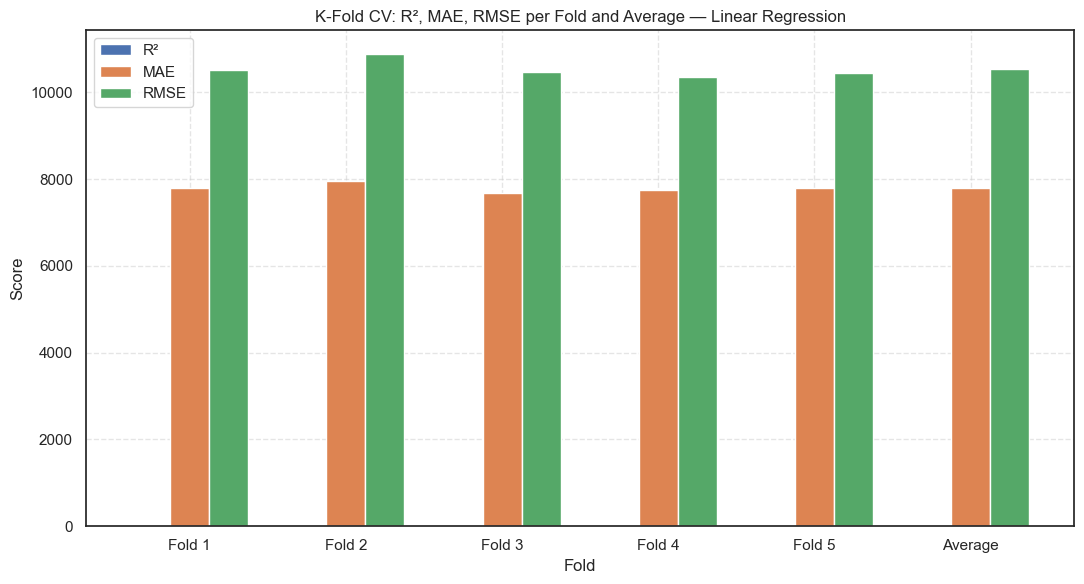

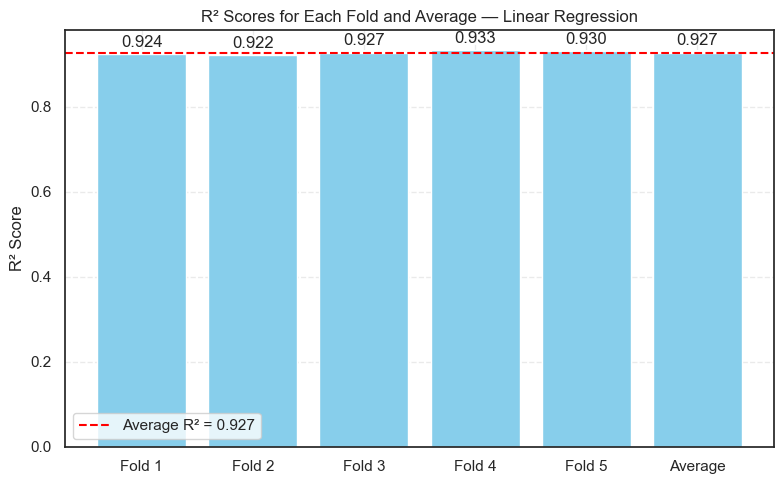


SVR (Linear, C=1000)
  Fold 1: R2=0.9231, MAE=7,763, RMSE=10,604
  Fold 2: R2=0.9212, MAE=7,895, RMSE=10,908
  Fold 3: R2=0.9262, MAE=7,697, RMSE=10,531
  Fold 4: R2=0.9309, MAE=7,786, RMSE=10,496
  Fold 5: R2=0.9282, MAE=7,784, RMSE=10,574
  Avg   : R2=0.9259, MAE=7,785, RMSE=10,623


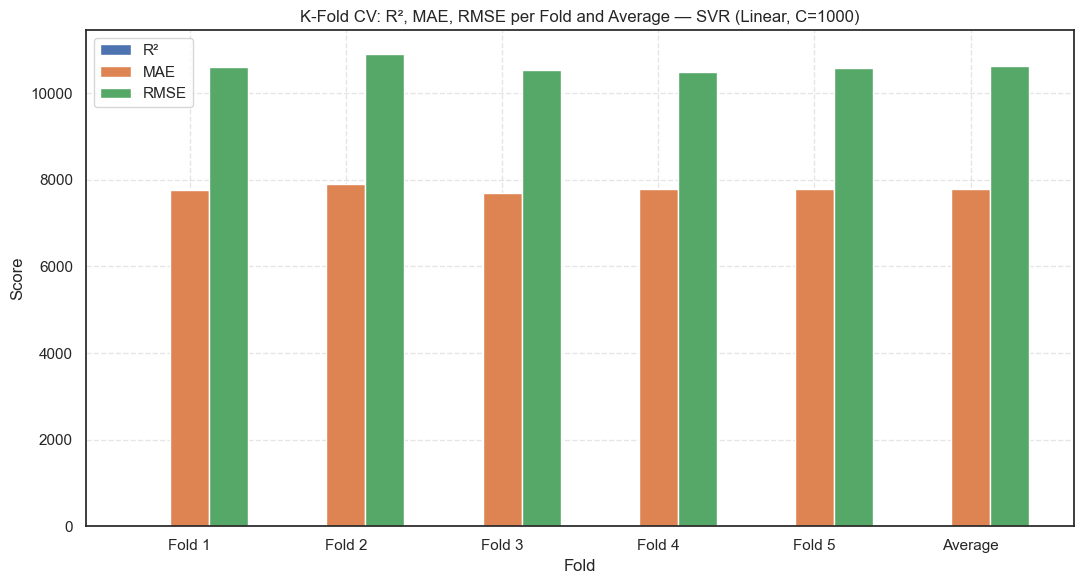

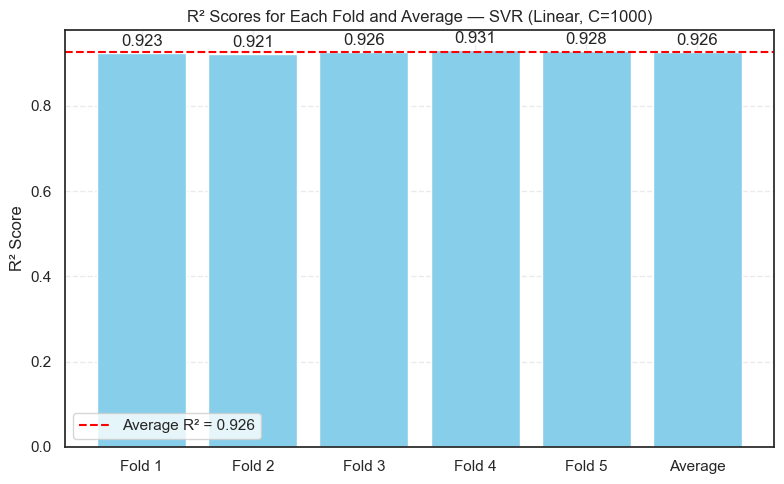


Random Forest
  Fold 1: R2=0.9895, MAE=2,592, RMSE=3,927
  Fold 2: R2=0.9883, MAE=2,573, RMSE=4,196
  Fold 3: R2=0.9901, MAE=2,551, RMSE=3,862
  Fold 4: R2=0.9892, MAE=2,648, RMSE=4,154
  Fold 5: R2=0.9901, MAE=2,517, RMSE=3,928
  Avg   : R2=0.9894, MAE=2,576, RMSE=4,013


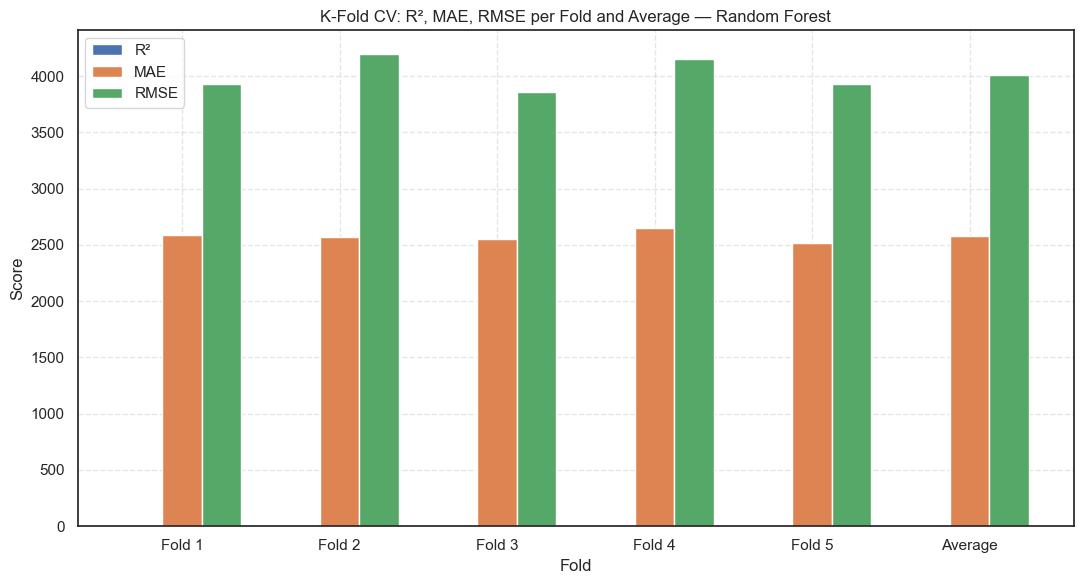

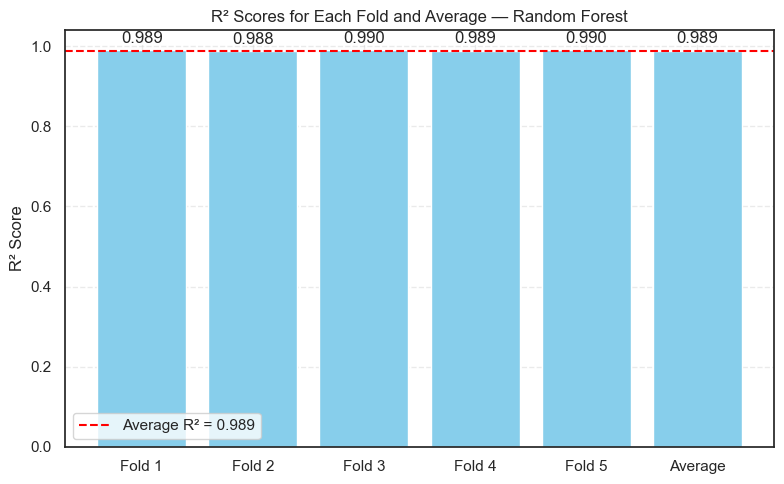

In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ----------------------------
# Load & tidy data
# ----------------------------
SECOND_DATA_PATH = "second_collected_data.csv"  # or "/mnt/data/first_collected_data.csv"
df = pd.read_csv(SECOND_DATA_PATH)
df.columns = df.columns.str.strip().str.replace(r"\s+$", "", regex=True)
df = df.rename(columns={"Type of Building":"Type", "Initial Cost ":"Initial Cost", "Area ":"Area"})

# clean strings
for c in ["Type","Location","Country","Material"]:
    if c in df.columns: df[c] = df[c].astype(str).str.strip()
# numerics
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")

feat_cols = [c for c in ["Type","Area","Year","Location","Country","Number of Floors","Material"] if c in df.columns]
target = "Initial Cost"
df = df.dropna(subset=feat_cols + [target]).reset_index(drop=True)

X = df[feat_cols].copy()
y = df[target].astype(float).values

# ----------------------------
# Preprocessors (version-safe OHE)
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)         # older sklearn

cat_cols = [c for c in ["Type","Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

pre_lr_rf = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)
pre_svr = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", MinMaxScaler(), num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

models = {
    "Linear Regression": Pipeline([("pre", pre_lr_rf), ("model", LinearRegression())]),
    "SVR (Linear, C=1000)": Pipeline([("pre", pre_svr), ("model", SVR(kernel="linear", C=1000, epsilon=0.1))]),
    "Random Forest": Pipeline([("pre", pre_lr_rf), ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))]),
}

# ----------------------------
# K-fold evaluation helper
# ----------------------------
def eval_kfold(pipe, X, y, n_splits=5, seed=42):
    n_splits = max(2, min(n_splits, len(X)))  # safety for small data
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    r2_scores, mae_scores, rmse_scores = [], [], []
    for tr, te in kf.split(X):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y[tr], y[te]

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)

        r2_scores.append(r2_score(y_te, y_pred))
        mae_scores.append(mean_absolute_error(y_te, y_pred))
        rmse_scores.append(np.sqrt(((y_te - y_pred) ** 2).mean()))

    return np.array(r2_scores), np.array(mae_scores), np.array(rmse_scores)

def plot_grouped_bars(name, r2, mae, rmse, save_prefix=None):
    # Append averages at the end (like your plot)
    r2_list  = list(r2)  + [np.mean(r2)]
    mae_list = list(mae) + [np.mean(mae)]
    rmse_list= list(rmse)+ [np.mean(rmse)]

    labels = [f"Fold {i+1}" for i in range(len(r2))] + ["Average"]
    x = np.arange(len(labels)); width = 0.25

    plt.figure(figsize=(11, 6))
    plt.bar(x - width, r2_list,  width, label="R²")
    plt.bar(x,          mae_list, width, label="MAE")
    plt.bar(x + width,  rmse_list,width, label="RMSE")
    plt.title(f"K-Fold CV: R², MAE, RMSE per Fold and Average — {name}")
    plt.xlabel("Fold"); plt.ylabel("Score")
    plt.xticks(x, labels)
    plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_all_metrics.png", dpi=200)
    plt.show()

def plot_r2_only(name, r2, save_prefix=None):
    avg = np.mean(r2)
    labels = [f"Fold {i+1}" for i in range(len(r2))] + ["Average"]
    values = list(r2) + [avg]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color="skyblue")
    plt.axhline(avg, color="red", linestyle="--", label=f"Average R² = {avg:.3f}")
    for b in bars:
        h = b.get_height()
        plt.annotate(f"{h:.3f}", (b.get_x()+b.get_width()/2, h), xytext=(0,3),
                     textcoords="offset points", ha="center", va="bottom")
    plt.title(f"R² Scores for Each Fold and Average — {name}")
    plt.ylabel("R² Score"); plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(); plt.tight_layout()
    if save_prefix: plt.savefig(f"{save_prefix}_r2_only.png", dpi=200)
    plt.show()

# ----------------------------
# Run & plot per model
# ----------------------------
for name, pipe in models.items():
    r2, mae, rmse = eval_kfold(pipe, X, y, n_splits=5, seed=42)
    print(f"\n{name}")
    for i,(r, m, s) in enumerate(zip(r2, mae, rmse), 1):
        print(f"  Fold {i}: R2={r:.4f}, MAE={m:,.0f}, RMSE={s:,.0f}")
    print(f"  Avg   : R2={np.mean(r2):.4f}, MAE={np.mean(mae):,.0f}, RMSE={np.mean(rmse):,.0f}")

    # plots (save_prefix optional; set to a string to save PNGs)
    save_prefix = None  # e.g., f"kfold_{name.replace(' ','_').replace('(','').replace(')','')}"
    plot_grouped_bars(name, r2, mae, rmse, save_prefix=save_prefix)
    plot_r2_only(name, r2, save_prefix=save_prefix)


***Feature Importance Random Forest***


Top 20 Most Important Features:

                             Feature  Importance
0                               Area    0.374480
1                               Year    0.265714
2   Material_Vinyl Siding Wood Frame    0.044351
3                       Type_Modular    0.037944
4                  Type_Conventional    0.037650
5                Location_California    0.027058
6                 Location_New Jersy    0.022374
7                  Location_New York    0.016280
8                  Location_Illinois    0.014296
9             Location_Massachusetts    0.012954
10                  Number of Floors    0.011853
11                 Location_Delaware    0.011649
12              Location_Connecticut    0.011250
13     Material_Stucco On Wood Frame    0.010635
14                        Country_US    0.009436
15                    Country_Canada    0.007712
16             Location_Pennsylvania    0.006741
17  Material_Brick Veneer Wood Frame    0.006158
18                Location_Minnesot

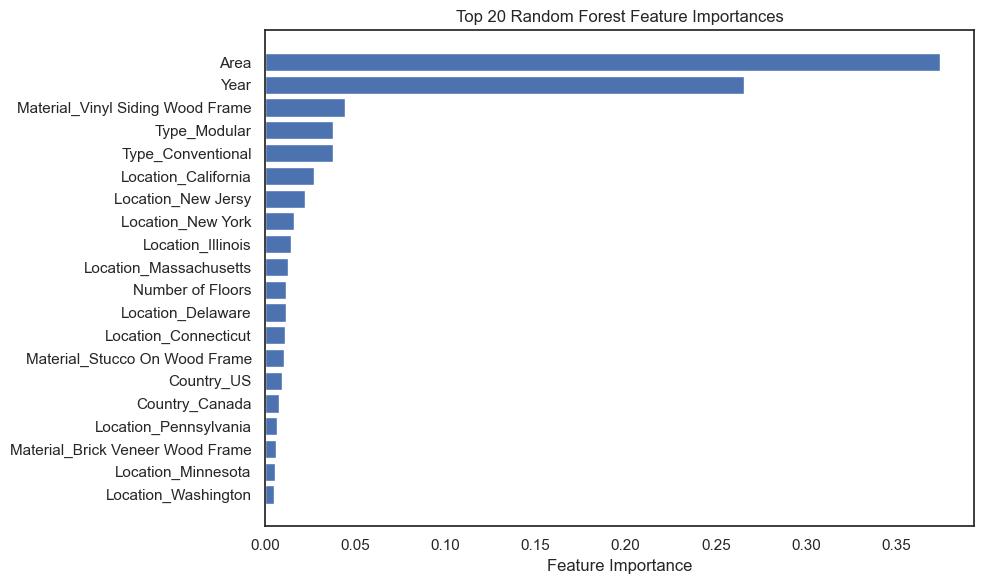

In [18]:
import pandas as pd, numpy as np, joblib, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# ----------------------------
# Paths
# ----------------------------
SECOND_DATA_PATH  = "second_collected_data.csv"         # or "/mnt/data/first_collected_data.csv"
SECOND_MODEL_PATH = "best_auto_model_secondcollected.joblib"
TOP_N      = 20                                  # how many features to show in the plot

# ----------------------------
# Load & tidy data
# ----------------------------
df = pd.read_csv(SECOND_DATA_PATH)
df.columns = df.columns.str.strip().str.replace(r"\s+$","", regex=True)
df = df.rename(columns={"Type of Building":"Type","Initial Cost ":"Initial Cost","Area ":"Area"})

# clean strings
for c in ["Type","Location","Country","Material"]:
    if c in df.columns: df[c] = df[c].astype(str).str.strip()
# numerics
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")

feat_cols = [c for c in ["Type","Area","Year","Location","Country","Number of Floors","Material"] if c in df.columns]
target = "Initial Cost"

df = df.dropna(subset=feat_cols + [target]).reset_index(drop=True)
X = df[feat_cols].copy()
y = df[target].astype(float).values

# ----------------------------
# Helper: version-safe OneHotEncoder
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)         # older versions

cat_cols = [c for c in ["Type","Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

pre_for_rf = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

# ----------------------------
# Load best pipeline; use if it's RF, else fit an RF pipeline
# ----------------------------
pipe = joblib.load(SECOND_MODEL_PATH)
last_step_name = list(pipe.named_steps.keys())[-1]
final_estimator = pipe.named_steps[last_step_name]

if isinstance(final_estimator, RandomForestRegressor):
    # Use the saved (already-fitted) RF pipeline
    rf_pipe = pipe
    rf_model = final_estimator
    pre = rf_pipe.named_steps.get("pre", pre_for_rf)
else:
    # Refit a RandomForest with the same preprocessing
    rf_pipe = Pipeline([
        ("pre", pre_for_rf),
        ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))
    ])
    rf_pipe.fit(X, y)
    rf_model = rf_pipe.named_steps["model"]
    pre = rf_pipe.named_steps["pre"]

# ----------------------------
# Get expanded feature names + importances
# ----------------------------
# If the preprocessor is already fitted, get names directly; else fit on X to derive names
try:
    feature_names = pre.get_feature_names_out()
except Exception:
    pre.fit(X)
    feature_names = pre.get_feature_names_out()

importances = rf_model.feature_importances_

# Sanity check
assert len(importances) == len(feature_names), \
    f"Mismatch: {len(importances)} importances vs {len(feature_names)} features."

# ----------------------------
# Build importance table
# ----------------------------
importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
      .sort_values("Importance", ascending=False)
      .reset_index(drop=True)
)

# Print top N
top_n = min(TOP_N, len(importance_df))
print(f"\nTop {top_n} Most Important Features:\n")
print(importance_df.head(top_n))

# ----------------------------
# Plot top N as horizontal bar chart
# ----------------------------
top_features = importance_df.head(top_n)
plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


***Coefficient for Regression***


Linear Regression intercept: -28166887.392986313

Top 20 LR coefficients by |value|:
                              Feature   Coefficient           Abs
0                Location_California  53003.822513  53003.822513
1                 Location_New Jersy  48692.445412  48692.445412
2                  Location_New York  39745.450518  39745.450518
3             Location_Massachusetts  34513.925199  34513.925199
4                  Location_Illinois  33110.326247  33110.326247
5               Location_Connecticut  30666.459631  30666.459631
6                  Location_Delaware  24095.345215  24095.345215
7   Material_Vinyl Siding Wood Frame -22256.122242  22256.122242
8                       Type_Modular -22256.122242  22256.122242
9                  Type_Conventional  22256.122242  22256.122242
10                 Location_Arkansas -22184.914019  22184.914019
11                    Location_Texas -22069.215385  22069.215385
12              Location_Mississippi -21667.554785  21667.554785
13 

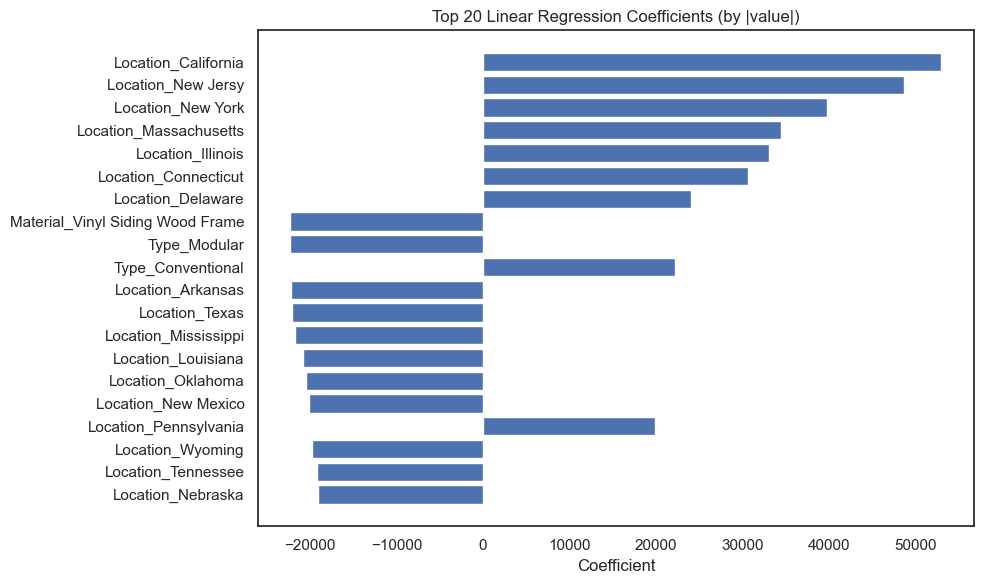

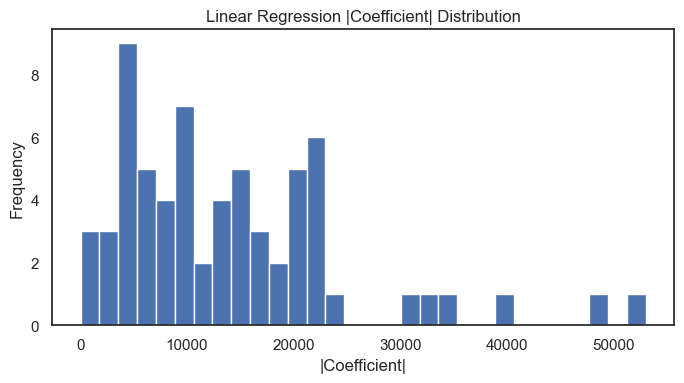

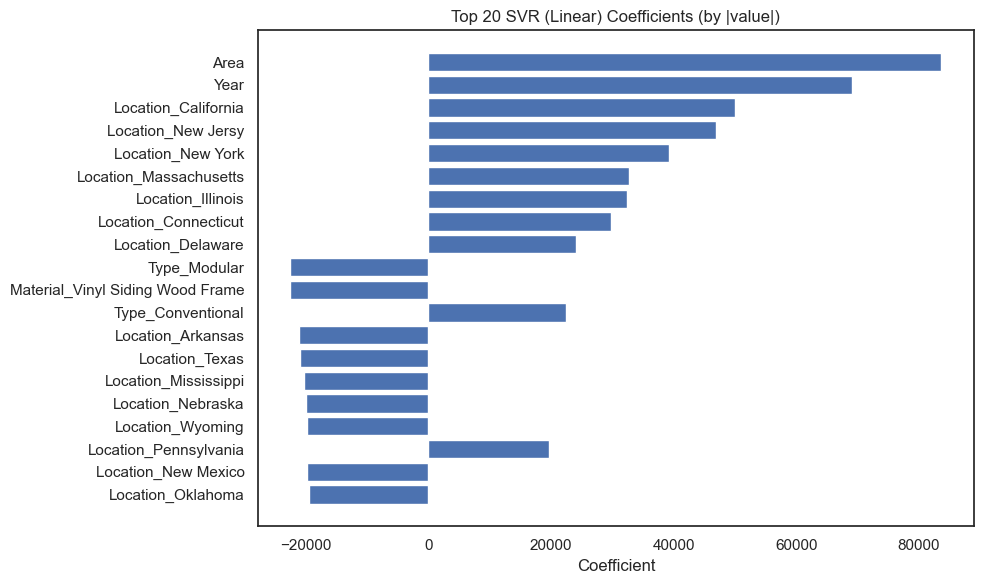

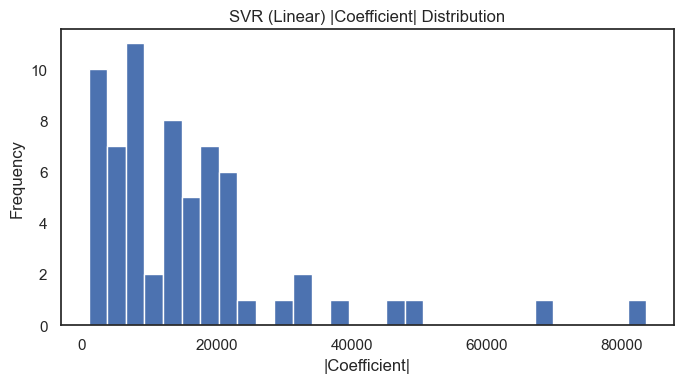

In [19]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# ----------------------------
# Load & tidy current dataset
# ----------------------------
SECOND_DATA_PATH = "second_collected_data.csv"  # change path if needed
df = pd.read_csv(SECOND_DATA_PATH)
df.columns = df.columns.str.strip().str.replace(r"\s+$","", regex=True)
df = df.rename(columns={"Type of Building":"Type","Initial Cost ":"Initial Cost","Area ":"Area"})

for c in ["Type","Location","Country","Material"]:
    if c in df.columns: df[c] = df[c].astype(str).str.strip()
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")

feat_cols = [c for c in ["Type","Area","Year","Location","Country","Number of Floors","Material"] if c in df.columns]
target = "Initial Cost"
df = df.dropna(subset=feat_cols + [target]).reset_index(drop=True)

X = df[feat_cols].copy()
y = df[target].astype(float).values

# ----------------------------
# Version-safe OneHotEncoder
# ----------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)         # older versions

cat_cols = [c for c in ["Type","Location","Country","Material"] if c in X.columns]
num_cols = [c for c in ["Area","Year","Number of Floors"] if c in X.columns]

pre_lr = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", "passthrough", num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

pre_svr = ColumnTransformer(
    [("cat", make_ohe(), cat_cols),
     ("num", MinMaxScaler(), num_cols)],
    remainder="drop", verbose_feature_names_out=False
)

# ----------------------------
# Fit Linear Regression & get coefficients
# ----------------------------
lr_pipe = Pipeline([("pre", pre_lr), ("model", LinearRegression())])
lr_pipe.fit(X, y)
lr_model = lr_pipe.named_steps["model"]
lr_feat_names = lr_pipe.named_steps["pre"].get_feature_names_out()

lr_coef = lr_model.coef_.ravel()                 # shape (n_features,)
lr_intercept = float(lr_model.intercept_)

lr_df = (pd.DataFrame({"Feature": lr_feat_names, "Coefficient": lr_coef})
           .assign(Abs=lambda d: d["Coefficient"].abs())
           .sort_values("Abs", ascending=False)
           .reset_index(drop=True))

print("\nLinear Regression intercept:", lr_intercept)
print("\nTop 20 LR coefficients by |value|:\n", lr_df.head(20))

# ----------------------------
# Fit SVR (linear kernel) & get coefficients
#   For SVR(kernel='linear'), weight vector w = dual_coef_ @ support_vectors_
#   (these are already in transformed feature space).
# ----------------------------
svr_pipe = Pipeline([("pre", pre_svr), ("model", SVR(kernel="linear", C=1000, epsilon=0.1))])
svr_pipe.fit(X, y)
svr_model = svr_pipe.named_steps["model"]
svr_feat_names = svr_pipe.named_steps["pre"].get_feature_names_out()

# Some sklearn versions expose coef_; otherwise compute from dual + SVs
if hasattr(svr_model, "coef_"):
    w = svr_model.coef_.ravel()
else:
    w = (svr_model.dual_coef_ @ svr_model.support_vectors_).ravel()
svr_intercept = float(svr_model.intercept_.ravel()[0])

svr_df = (pd.DataFrame({"Feature": svr_feat_names, "Coefficient": w})
            .assign(Abs=lambda d: d["Coefficient"].abs())
            .sort_values("Abs", ascending=False)
            .reset_index(drop=True))

print("\nSVR (linear) intercept:", svr_intercept)
print("\nTop 20 SVR coefficients by |value|:\n", svr_df.head(20))

# ----------------------------
# Plots: top-N bars + (optional) histograms
# ----------------------------
TOP_N = 20  # adjust for how many top coefficients to display

def plot_top_bars(df_coef, title, top_n=20):
    top = df_coef.head(min(top_n, len(df_coef)))
    plt.figure(figsize=(10, 6))
    plt.barh(top["Feature"], top["Coefficient"])
    plt.title(title)
    plt.xlabel("Coefficient")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_abs_hist(df_coef, title):
    plt.figure(figsize=(7, 4))
    plt.hist(df_coef["Abs"].values, bins=30)
    plt.title(title)
    plt.xlabel("|Coefficient|")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# LR plots
plot_top_bars(lr_df, f"Top {TOP_N} Linear Regression Coefficients (by |value|)", TOP_N)
plot_abs_hist(lr_df, "Linear Regression |Coefficient| Distribution")

# SVR plots
plot_top_bars(svr_df, f"Top {TOP_N} SVR (Linear) Coefficients (by |value|)", TOP_N)
plot_abs_hist(svr_df, "SVR (Linear) |Coefficient| Distribution")


***Sensitivity Analysis***

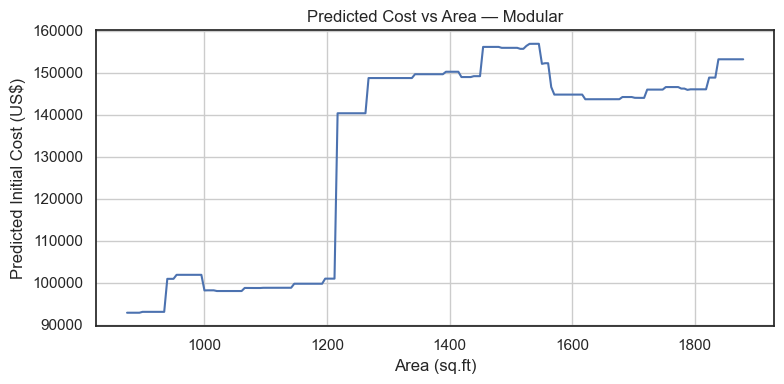

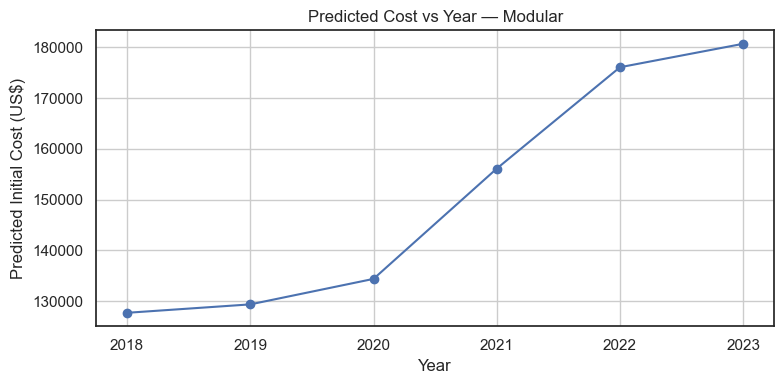

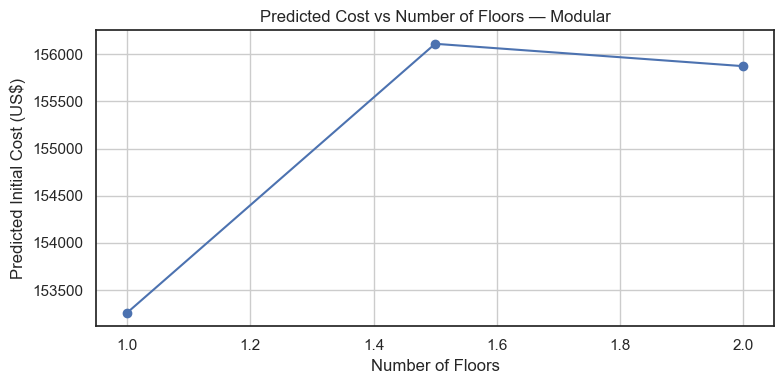

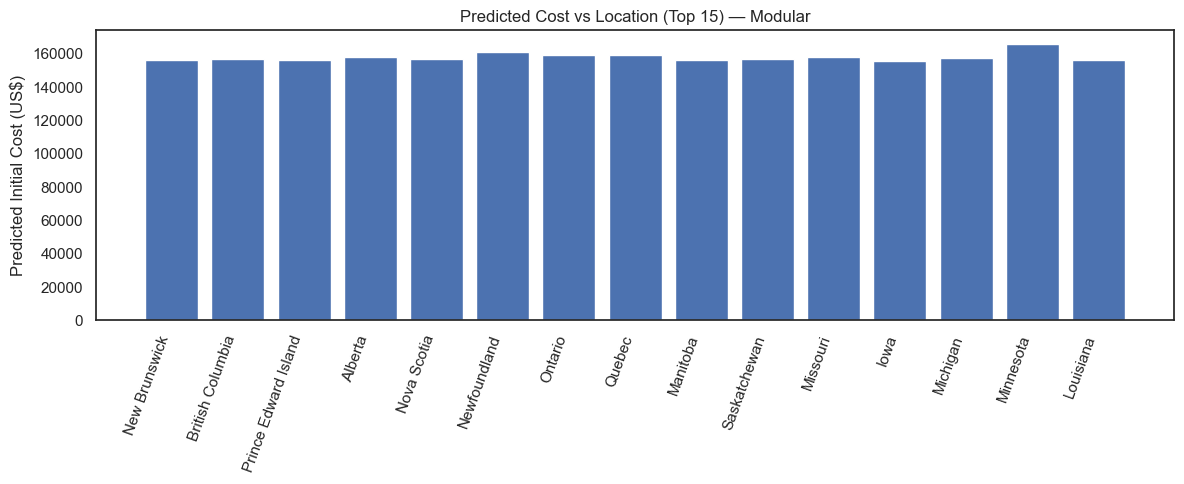

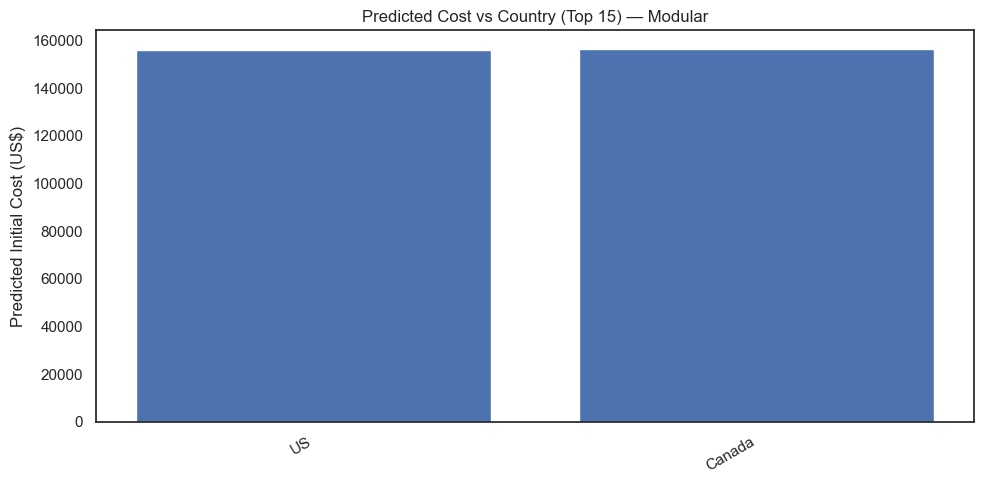

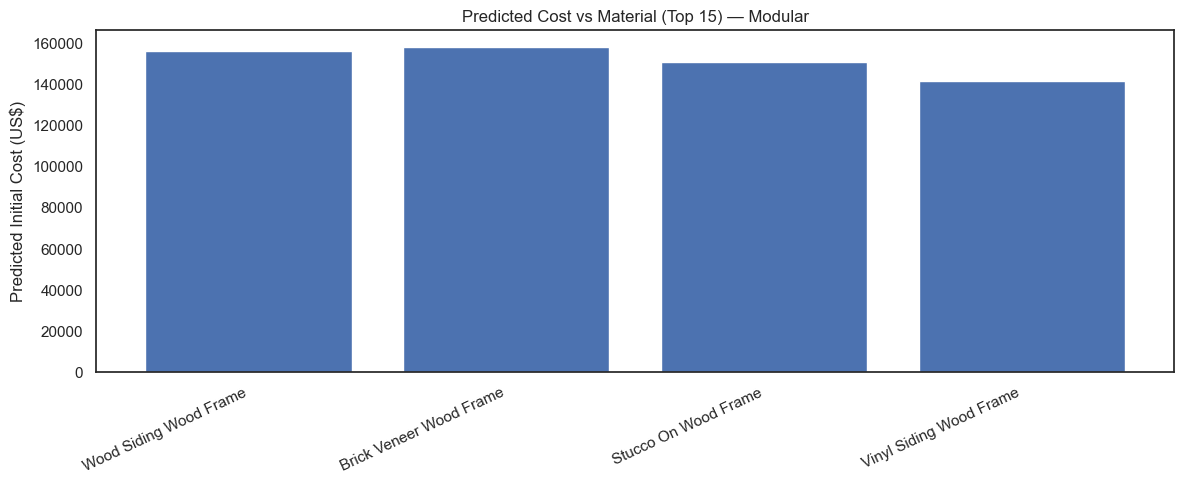

In [20]:
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt

SECOND_DATA = "second_collected_data.csv"
SECOND_MODEL = "best_auto_model_secondcollected.joblib"

# -------------------------
# 1) Load data & model
# -------------------------
df = pd.read_csv(SECOND_DATA)
df.columns = df.columns.str.strip().str.replace(r"\s+$", "", regex=True)
df = df.rename(columns={"Type of Building":"Type", "Initial Cost ":"Initial Cost", "Area ":"Area"})

# basic cleaning
for c in ["Type","Location","Country","Material"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()
for c in ["Area","Year","Number of Floors","Initial Cost"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# keep only rows with all needed features present
features = ["Type","Area","Year","Location","Country","Number of Floors","Material"]
target   = "Initial Cost"
avail = [c for c in features + [target] if c in df.columns]
df = df.dropna(subset=avail).reset_index(drop=True)

model = joblib.load(SECOND_MODEL)   # full Pipeline(preprocessor, estimator)

# -------------------------
# 2) Helpers (fixed values & probe builders)
# -------------------------
def typical_values(frame: pd.DataFrame) -> dict:
    """Return typical values (median/mode) for all features except Type."""
    return {
        "Year": int(pd.to_numeric(frame["Year"], errors="coerce").median()),
        "Number of Floors": float(pd.to_numeric(frame["Number of Floors"], errors="coerce").median()),
        "Location": frame["Location"].mode().iat[0],
        "Country": frame["Country"].mode().iat[0],
        "Material": frame["Material"].mode().iat[0],
        "Area": float(pd.to_numeric(frame["Area"], errors="coerce").median()),
    }

FX = typical_values(df)

def predict_over_numeric(var: str, grid, type_label="Modular") -> pd.DataFrame:
    """Build a probe over numeric variable `var` with others fixed, then predict."""
    n = len(grid)
    probe = {
        "Type": [type_label]*n,
        "Area": [FX["Area"]]*n,
        "Year": [FX["Year"]]*n,
        "Location": [FX["Location"]]*n,
        "Country": [FX["Country"]]*n,
        "Number of Floors": [FX["Number of Floors"]]*n,
        "Material": [FX["Material"]]*n,
    }
    probe[var] = grid
    probe = pd.DataFrame(probe)
    yhat = model.predict(probe)
    return pd.DataFrame({var: grid, "Predicted Cost": yhat})

def predict_over_categories(var: str, categories, type_label="Modular") -> pd.DataFrame:
    """Build a probe across categorical levels in `categories` with others fixed."""
    probe = pd.DataFrame({
        "Type": [type_label]*len(categories),
        "Area": [FX["Area"]]*len(categories),
        "Year": [FX["Year"]]*len(categories),
        "Location": [FX["Location"]]*len(categories),
        "Country": [FX["Country"]]*len(categories),
        "Number of Floors": [FX["Number of Floors"]]*len(categories),
        "Material": [FX["Material"]]*len(categories),
    })
    probe[var] = categories
    yhat = model.predict(probe)
    return pd.DataFrame({var: categories, "Predicted Cost": yhat})

# -------------------------
# 3) Configure & plot
# -------------------------
TYPE_OF_INTEREST = "Modular"     # change to "Conventional" if you want
TOP_K_CATS = 15                  # bars will show top-K categories by frequency

# A) Predicted Cost vs Area (line over observed range)
area_min, area_max = df["Area"].min(), df["Area"].max()
area_grid = np.linspace(area_min, area_max, 200)
res_area = predict_over_numeric("Area", area_grid, TYPE_OF_INTEREST)
plt.figure(figsize=(8,4))
plt.plot(res_area["Area"], res_area["Predicted Cost"])
plt.title(f"Predicted Cost vs Area — {TYPE_OF_INTEREST}")
plt.xlabel("Area (sq.ft)"); plt.ylabel("Predicted Initial Cost (US$)")
plt.grid(True); plt.tight_layout(); plt.show()

# B) Predicted Cost vs Year (line over observed years)
years = sorted(df["Year"].unique().astype(int))
res_year = predict_over_numeric("Year", years, TYPE_OF_INTEREST)
plt.figure(figsize=(8,4))
plt.plot(res_year["Year"], res_year["Predicted Cost"], marker="o")
plt.title(f"Predicted Cost vs Year — {TYPE_OF_INTEREST}")
plt.xlabel("Year"); plt.ylabel("Predicted Initial Cost (US$)")
plt.grid(True); plt.xticks(years); plt.tight_layout(); plt.show()

# C) Predicted Cost vs Number of Floors (line over observed floors)
floors = sorted(df["Number of Floors"].unique())
res_floors = predict_over_numeric("Number of Floors", floors, TYPE_OF_INTEREST)
plt.figure(figsize=(8,4))
plt.plot(res_floors["Number of Floors"], res_floors["Predicted Cost"], marker="o")
plt.title(f"Predicted Cost vs Number of Floors — {TYPE_OF_INTEREST}")
plt.xlabel("Number of Floors"); plt.ylabel("Predicted Initial Cost (US$)")
plt.grid(True); plt.tight_layout(); plt.show()

# D) Predicted Cost vs Location (bar — top K locations)
top_locations = df["Location"].value_counts().nlargest(TOP_K_CATS).index.tolist()
res_loc = predict_over_categories("Location", top_locations, TYPE_OF_INTEREST)
plt.figure(figsize=(12,5))
plt.bar(res_loc["Location"], res_loc["Predicted Cost"])
plt.title(f"Predicted Cost vs Location (Top {TOP_K_CATS}) — {TYPE_OF_INTEREST}")
plt.ylabel("Predicted Initial Cost (US$)")
plt.xticks(rotation=70, ha="right"); plt.tight_layout(); plt.show()

# E) Predicted Cost vs Country (bar — top K countries)
top_countries = df["Country"].value_counts().nlargest(TOP_K_CATS).index.tolist()
res_ctry = predict_over_categories("Country", top_countries, TYPE_OF_INTEREST)
plt.figure(figsize=(10,5))
plt.bar(res_ctry["Country"], res_ctry["Predicted Cost"])
plt.title(f"Predicted Cost vs Country (Top {TOP_K_CATS}) — {TYPE_OF_INTEREST}")
plt.ylabel("Predicted Initial Cost (US$)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

# F) Predicted Cost vs Material (bar — top K materials)
top_materials = df["Material"].value_counts().nlargest(TOP_K_CATS).index.tolist()
res_mat = predict_over_categories("Material", top_materials, TYPE_OF_INTEREST)
plt.figure(figsize=(12,5))
plt.bar(res_mat["Material"], res_mat["Predicted Cost"])
plt.title(f"Predicted Cost vs Material (Top {TOP_K_CATS}) — {TYPE_OF_INTEREST}")
plt.ylabel("Predicted Initial Cost (US$)")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()
